# Begin

Courtesy: https://docs.cleanrl.dev/rl-algorithms/ppo-trxl/

In [1]:
# @launchit.collected

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import socket
import copy
from collections import namedtuple, defaultdict, Counter, deque # @launchit.collect
import random
import math
import datetime
import json
import pprint
import re
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython 
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp
import queue

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
import torch.optim
import torch.multiprocessing as torch_mp
import torch._dynamo as dynamo
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Categorical

import gymnasium as gym
import ale_py
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
import av

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
project_root_path2 = '${PROJECT_ROOT_PATH2}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
sys.path.append(os.path.join(project_root_path2, 'lib')) # @launchit.collect
from cleanrl.cleanrl_utils.atari_wrappers import (  # isort:skip
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)
import lang_utils as lu # @launchit.collect
import array_utils as au # @launchit.collect
from math_utils import RecursiveAverageFilter, RecursiveMovingAverageFilter
from logging_utils import *
from artifact_registry import *
from torch_utils import *
import launchit 
import optuna_multiprocessing  # @launchit.collect
from hp_utils import *
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement
from curriculum_utils import *

/home/misha/anaconda3/envs/mine/lib/python3.12/site-packages/cupyx/scipy/__init__.py:10: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  import scipy as _scipy


# Init

In [3]:
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()
    
def create_config():
    config = namedtuple('Config', 
                        'host_name, ' +
                        'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, ' + 
                        'self_fname, self_name, ' +
                        'subproject_name,' +
                        'is_cuda, cuda_device, exec_mode, is_interactive')(
        host_name=socket.gethostname(),
        project_root_path=project_root_path,
        project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
        model_group_uri=None,
        subproject_path=os.path.abspath('.'),
        data_path=os.path.join(project_root_path, 'data'),
        private_data_path=None,
        run_path=None,
        self_fname=None,
        self_name=None,
        subproject_name=None,
        is_cuda=torch.cuda.is_available(),
        cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
        exec_mode=ExecMode.MASTER_NOTEBOOK,
        is_interactive=True,
    )
    
    if IPython.get_ipython() is None:
        module_fname = __file__
        module_basename = os.path.basename(module_fname)
        module_name, _ = os.path.splitext(module_basename)
        
        config = config._replace(self_fname=module_fname, self_name=module_name)
        config = config._replace(exec_mode=ExecMode.LAUNCH_MODULE)
    else:
        with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
            notebook_fname = json.load(cf).get('jupyter_session')

            if notebook_fname is None:
                notebook_fname = os.path.join(config.subproject_path, os.path.basename('${LAUNCHIT_FNAME}'))
                assert os.path.exists(notebook_fname)
            
            notebook_basename = os.path.basename(notebook_fname)
            notebook_name, notebook_ext = os.path.splitext(notebook_basename)
        
            m = re.match(r'(\w+)-Copy\d+$', notebook_name)
        
            if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook
    
            config = config._replace(self_fname=notebook_fname, self_name=notebook_name)
            
            is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
            config = config._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)
    
    config = config._replace(is_interactive=config.exec_mode != ExecMode.LAUNCH_MODULE)    
    config = config._replace(subproject_name=os.path.basename(os.path.dirname(config.self_fname)))
    config = config._replace(model_group_uri=f'{config.project_root_uri}.{config.subproject_name}')
    config = config._replace(run_path=os.path.join(project_root_path, 'run', config.subproject_name))
    config = config._replace(private_data_path=os.path.join(config.data_path, config.subproject_name))
    return config

In [4]:
# @launchit.disable_2
au.init()
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)
CONFIG = create_config()
LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)
os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'host_name': 'thinkbook',
 'project_root_path': '/home/misha/dev/mine/neurolab',
 'project_root_uri': 'com.develorium.neurolab',
 'model_group_uri': 'com.develorium.neurolab.17_rl',
 'subproject_path': '/home/misha/dev/mine/neurolab/17_rl',
 'data_path': '/home/misha/dev/mine/neurolab/data',
 'private_data_path': '/home/misha/dev/mine/neurolab/data/17_rl',
 'run_path': '/home/misha/dev/mine/neurolab/run/17_rl',
 'self_fname': '/home/misha/dev/mine/neurolab/17_rl/17e_ppo_tr_atari_mp_10.ipynb',
 'self_name': '17e_ppo_tr_atari_mp_10',
 'subproject_name': '17_rl',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [5]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN = auto()
    WORKER = auto()

LaunchComponent = namedtuple('LaunchComponent', 'name version uri main_asset_fname')
    
@dataclass(slots=True)
class Hyperparameters:
    # Launch
    launch_goal: LaunchGoal = lu.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED)
    launch_id: int = lu.from_str(int, '${MODEL_VERSION}', 0)

    @dataclass(slots=True)
    class System:
        comment: str = None
        random_seed: int = None
        is_torch_deterministic: bool = True
        is_torch_compile: bool = False

    @dataclass(slots=True)
    class Env:
        ident: str = None
        render_mode: str = None
        count: int = 1 # number of parallel game environments
        is_episodic_life: bool = None
        actions_count: int = None # None - consider all actions, otherwise take only first :actions_count

    @dataclass(slots=True)
    class Agent:
        layers_count: int = 3 # number of transformer layers
        heads_count: int = 4 # number of heads used in multi-head attention
        d_model: int = 384 # dimension of the transformer
        obs_sequence_length: int = 10 # observations chain max length
        action_plan_length: int = 10 # number of actions agent must think upfront about
        positional_encoding: str = 'absolute' # absolute (sinusoidal), learned

    @dataclass(slots=True)
    class Video:
        capture_policy: str = 'every(1000000)' # video capture policy depending on steps
        
    @dataclass(slots=True)
    class PPO:
        global_steps_count: int = 1_000_000 # total number of steps 
        rollout_steps_count: int = 512 # how many steps to run in a single policy rolllout
        minibatches_count: int = 8
        epochs_count: int = 3 
        gamma: float = 0.995 # return discount factor gamma
        gae_lambda: float = 0.95 # lambda for the general advantage estimation
        clip_coef: float = 0.1 # the surrogate clipping coefficient
        clip_vloss: bool = True # Toggles whether or not to use a clipped loss for the value function, as per the paper
        vf_coef: float = 0.5 # coefficient of the value function
        max_grad_norm: float = 0.25 # the maximum norm for the gradient clipping
        target_kl: float = None # e target KL divergence threshold
        norm_adv: bool = False # Toggles advantages normalization
        prediction_coef: float = 0.0 # coefficient of the loss for observation emb. prediction, if set to 0.0 the prediction loss is not used
        tau: float = 0.0 # temperature for action logits annealing
        optimizer: str = 'AdamW'
        is_parallel_teacher_forcing: bool = None # whether to train on whole sequence (True) or just on a last element (False)

    system: System = dataclasses.field(default_factory=System)
    env: Env = dataclasses.field(default_factory=Env)
    agent: Agent = dataclasses.field(default_factory=Agent)
    video: Video = dataclasses.field(default_factory=Video)
    ppo: PPO = dataclasses.field(default_factory=PPO)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.system = Hyperparameters.System(**hp.system)
        hp.env = Hyperparameters.Env(**hp.env)
        hp.agent = Hyperparameters.Agent(**hp.agent)
        hp.video = Hyperparameters.Video(**hp.video)
        hp.ppo = Hyperparameters.PPO(**hp.ppo)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

    def launch_component(self):
        name = lu.when('${MODEL_NAME}' == '$' + '{MODEL_NAME}', CONFIG.self_name, '${MODEL_NAME}')
        return LaunchComponent(name=name, version=self.launch_id,  uri=f'{CONFIG.model_group_uri}.{name}', main_asset_fname=CONFIG.self_fname)

HP = Hyperparameters()

# Launch

## LaunchState

In [6]:
@dataclass(slots=True)
class LaunchState:
    mp_ctx: object = None
    env_observation_space_shape: object = None
    env_action_space_shape: object = None
    agent: object = None
    capture_video_worker: object = None
    curriculum: object = None

    @staticmethod
    def new_artifact_registry(is_real=None):
        is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
        is_real = lu.coalesce(is_real, is_launch)
    
        if not is_real:
            mr = Mock()
            mr.register_model.return_value = 0
            return mr
            
        return ArtifactRegistry(CONFIG.model_group_uri)

    @staticmethod
    def new_summary_writer(log_dir, is_real=None):
        is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
        is_real = lu.coalesce(is_real, is_launch)
    
        if not is_real:
            sw = Mock()
            sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
            return sw
        
        return RmqSummaryWriter(log_dir)

## Configure

In [7]:
# @launchit.disable
# @launchit.collect
HP.system.random_seed = 42
HP.system.is_torch_deterministic = True
HP.system.is_torch_compile = True
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'env': {'ident': None,
         'render_mode': None,
         'count': 1,
         'is_episodic_life': None,
         'actions_count': None},
 'agent': {'layers_count': 3,
           'heads_count': 4,
           'd_model': 384,
           'obs_sequence_length': 10,
           'action_plan_length': 10,
           'positional_encoding': 'absolute'},
 'video': {'capture_policy': 'every(1000000)'},
 'ppo': {'global_steps_count': 1000000,
         'rollout_steps_count': 512,
         'minibatches_count': 8,
         'epochs_count': 3,
         'gamma': 0.995,
         'gae_lambda': 0.95,
         'clip_coef': 0.1,
         'clip_vloss': True,
         'vf_coef': 0.5,
         'max_grad_norm': 0.25,
         'target_kl': None,
         'norm_adv': False,
         'prediction_co

## Create

In [8]:
# @launchit.disable_2
LS = LaunchState()
LS.mp_ctx = torch_mp.get_context('spawn') # Spawn is needed for CUDA, fork doesn't work within PyTorch

optuna_trial = optuna_multiprocessing.get_trial()
optuna_trial_subdir_name = ''

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', HP.launch_id)
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    optuna_trial_subdir_name = f'opt_{study_serial}'
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.system.random_seed is not None:
    random.seed(HP.system.random_seed)
    torch.manual_seed(HP.system.random_seed)
    RNG = np.random.default_rng(HP.system.random_seed)    
    LOG(f'Random seed={HP.system.random_seed}')

if HP.system.is_torch_deterministic is not None:
    torch.backends.cudnn.deterministic = HP.system.is_torch_deterministic
    LOG(f'{torch.backends.cudnn.deterministic=}')

lc = HP.launch_component()
artifact_registry = LS.new_artifact_registry()
artifact_registry.attach_asset(lc.name, lc.version, lc.main_asset_fname, replace=True)
    
meta = dict(
    optuna_trial_number=getattr(optuna_trial, 'number', None),
    hypers=HP._asdict(), 
    config=CONFIG._asdict(), 
)

with io.StringIO() as b:
    json.dump(meta, b)
    artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = lc.name
summary_log_dir = os.path.join(summary_log_dir, optuna_trial_subdir_name) if optuna_trial_subdir_name != '' else summary_log_dir 
summary_log_dir = os.path.join(summary_log_dir, str(lc.version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = LS.new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hyperparameters', pprint.pformat(HP._asdict(), sort_dicts=False), 0)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 0)

Random seed=42
torch.backends.cudnn.deterministic=True
Tensorboard run=17e_ppo_tr_atari_mp_10/0


<Mock name='mock.add_text()' id='134695064906992'>

# Environment

## MyUberWrapper

In [9]:
class MyUberWrapper(gym.vector.VectorWrapper):
    def __init__(self, env, params):
        super().__init__(env)
        self.is_atari_vector_env = isinstance(env, ale_py.AtariVectorEnv)
        self.frame_numbers = np.zeros(env.unwrapped.num_envs, dtype=np.int32)
        self.episode_lengths = np.zeros(env.unwrapped.num_envs, dtype=np.int32)
        self.episode_returns = np.zeros(env.unwrapped.num_envs)
        self.lives = np.zeros(env.unwrapped.num_envs, dtype=np.int32)
        self.was_life_lost = np.zeros(env.unwrapped.num_envs, dtype=np.bool)
        self.life_lengths = np.zeros(env.unwrapped.num_envs, dtype=np.int32)
        self.life_returns = np.zeros(env.unwrapped.num_envs)
        self.params = params

    def step(self, actions):
        self.life_lengths[self.was_life_lost] = 0
        self.life_returns[self.was_life_lost] = 0
        
        obs, rewards, terminations, truncations, infos = self.env.step(actions)
        
        if not self.is_atari_vector_env:
            assert '_lives' in infos, infos
            assert np.all(infos['_lives'] == True), infos
            assert np.all(infos['_frame_number'] == True), infos
            assert np.all(infos['_episode_frame_number'] == True), infos

        frame_numbers = infos['frame_number'] # grows indefinitely starting from ROM load
        episode_lengths = infos['episode_frame_number'] # resets on every new episode (game)
        lives = infos['lives']

        addon_lenghts = frame_numbers - self.frame_numbers
        self.frame_numbers[:] = frame_numbers
        assert np.all(addon_lenghts >= 0), addon_lenghts
        
        infos['is_episode_over'] = np.logical_or(terminations, truncations)
        self.episode_lengths[:] = episode_lengths
        self.episode_returns += rewards

        infos['is_life_lost'] = np.logical_or(lives < self.lives, infos['is_episode_over'])
        self.was_life_lost[:] = infos['is_life_lost']
        self.lives[:] = lives
        
        self.life_lengths += addon_lenghts
        self.life_returns += rewards

        infos['episode_lengths'] = self.episode_lengths.copy()
        infos['episode_returns'] = self.episode_returns.copy()
        infos['life_lengths'] = self.life_lengths.copy()
        infos['life_returns'] = self.life_returns.copy()

        return self._fix_obs(obs), self._clip_rewards(rewards), terminations, truncations, infos

    def reset(self, seed=None, options=None):
        obs, infos = self.env.reset(seed=seed, options=options)
        reset_mask = lu.coalesce(options, {}).get('reset_mask')

        if reset_mask is None:
            reset_mask = np.full(len(self.episode_lengths), True, dtype=np.bool)
            
        self.episode_lengths[reset_mask] = 0
        self.episode_returns[reset_mask] = 0
        self.life_lengths[reset_mask] = 0
        self.life_returns[reset_mask] = 0
        self.was_life_lost[reset_mask] = False
        return self._fix_obs(obs), infos

    def _fix_obs(self, obs):
        if self.is_atari_vector_env:
            # Get rid of dummy dimension cast by degenerate stack frames=1
            assert obs.ndim == 5, obs.shape # [num_envs, stack_size, height, width, 3]
            return obs.reshape(obs.shape[0], *obs.shape[2:])        
        else:
            assert obs.ndim == 4, obs.shape
            return obs

    def _clip_rewards(self, rewards):
        return np.sign(rewards)

## create_envs

In [10]:
def create_envs(envs_count):
    assert 'NoFrameskip-v4' in HP.env.ident
    env_id = HP.env.ident[:HP.env.ident.index('NoFrameskip')].lower()
    frameskip = 4
    
    envs = ale_py.AtariVectorEnv(
        game=env_id, 
        stack_num=1, # frame stacking is not needed because we use Transformer
        maxpool=True, # Combination of maxpool=True and 
        frameskip=frameskip, # frameskip=4 corresponds to MaxAndSkipEnv(env, skip=4)
        repeat_action_probability=0, # corresponds NoFrameskip-v4
        use_fire_reset=True, # FireResetEnv(env)
        noop_max=30, # NoopResetEnv(env, noop_max=30)
        
        episodic_life=False, # will manage episodic life our selves
        life_loss_info=False, # strange parameter. When set to True then program will segfault
        reward_clipping=False, # will clip reward in wrapper in order to keep original rewards for game stats accounting

        # Get raw observation since rescaling and grayscaling is done on GPU
        grayscale=False,
        img_height=210,
        img_width=160,
        
        num_envs=envs_count, 
        batch_size=0, # num of threads = num of envs
        num_threads=0, # kms@ think about making it e.g. 8 or the like (see ale/src/ale/vector/async_vectorizer.hpp)
        thread_affinity_offset=0,

        autoreset_mode=gym.vector.vector_env.AutoresetMode.DISABLED,
    )

    return MyUberWrapper(envs, params=dict(frameskip=frameskip))

## Configure 

In [11]:
# @launchit.disable
# @launchit.collect
HP.env.ident = 'FrostbiteNoFrameskip-v4'
HP.env.render_mode = 'rgb_array'
HP.env.count = 32 
HP.env.is_episodic_life = True
HP.env.actions_count = 6
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'env': {'ident': 'FrostbiteNoFrameskip-v4',
         'render_mode': 'rgb_array',
         'count': 32,
         'is_episodic_life': True,
         'actions_count': 6},
 'agent': {'layers_count': 3,
           'heads_count': 4,
           'd_model': 384,
           'obs_sequence_length': 10,
           'action_plan_length': 10,
           'positional_encoding': 'absolute'},
 'video': {'capture_policy': 'every(1000000)'},
 'ppo': {'global_steps_count': 1000000,
         'rollout_steps_count': 512,
         'minibatches_count': 8,
         'epochs_count': 3,
         'gamma': 0.995,
         'gae_lambda': 0.95,
         'clip_coef': 0.1,
         'clip_vloss': True,
         'vf_coef': 0.5,
         'max_grad_norm': 0.25,
         'target_kl': None,
         'norm_adv': Fals

## Create

In [12]:
# @launchit.disable_2
envs = create_envs(1)
print(envs)
assert isinstance(envs.single_action_space, gym.spaces.Discrete), f'Only discrete action spaces are supported, but got {type(env.single_action_space)}'
assert envs.single_observation_space.shape == (1, 210, 160, 3)
LS.env_observation_space_shape = envs.single_observation_space.shape
LS.env_action_space_shape = (lu.coalesce(HP.env.actions_count, envs.single_action_space.n.item()),)
assert len(LS.env_action_space_shape) == 1

LOG(f'{envs.metadata=}')
LOG(f'{envs.render_mode=}')
LOG(f'{LS.env_observation_space_shape=}')
LOG(f'{LS.env_action_space_shape=}')

del envs

<MyUberWrapper, AtariVectorEnv(num_envs=1)>
envs.metadata={'autoreset_mode': <AutoresetMode.DISABLED: 'Disabled'>}
envs.render_mode=None
LS.env_observation_space_shape=(1, 210, 160, 3)
LS.env_action_space_shape=(6,)


# Agent

## Components

### PositionalEncoding

In [13]:
# dialogs/positional_embedding.ipynb
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, min_timescale=2.0, max_timescale=1e4):
        super().__init__()
        freqs = torch.arange(0, d_model, min_timescale) # e.g. -> [0, 2, 4, ..., 382], len(freqs) = d_model // min_timescale
        inv_freqs = max_timescale ** (-freqs / d_model) # e.g. [1, 0.96, 0.93, ... 0.001]
        self.register_buffer("inv_freqs", inv_freqs) # declare as non trainable parameter but still part of a model (e.g. included in state_dict, obeys to(device), etc.)

    def forward(self, seq_len):
        seq = torch.arange(seq_len - 1, -1, -1.0, device=self.inv_freqs.device) # -> [seq_len-1, seq_len-2, ... 0]
        sinusoidal_inp = einops.rearrange(seq, 'n -> n 1') * einops.rearrange(self.inv_freqs, 'd -> 1 d') # n -> n () == n -> n 1
        pos_emb = torch.cat((sinusoidal_inp.sin(), sinusoidal_inp.cos()), dim=-1)
        return pos_emb # [seq_len, d_model]

### PredictionHead

In [14]:
class PredictionHead(nn.Module):
    def __init__(self, actions_count, d_model, action_d_model = 64):
        super().__init__()
        self.action_d_model = action_d_model
        self.action_embedding = nn.Embedding(actions_count, self.action_d_model) 
        self.network = nn.Sequential(
            nn.Linear(d_model + self.action_d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model)
        )

    def forward(self, transformer_outputs, actions):
        # transformer_outputs: [batch, (seq,)? d_model]
        # actions: [batch, (seq)?]
        act_emb = self.action_embedding(actions) # [batch, (seq,)? self.action_d_model]
        # Combine the history token with the action taken at that step
        combined = torch.cat([transformer_outputs, act_emb], dim=-1) # [batch, (seq,)? d_model + self.action_d_model]
        # Predict the next visual frame embedding
        return self.network(combined) # [batch, (seq,)? d_model]

## Agent

In [15]:
class Agent(nn.Module):
    @dataclass(slots=True)
    class Params:
        d_model: int = None
        layers_count: int = None
        heads_count: int = None
        positional_encoding: str = None
        observation_space_shape: tuple = (1, 84, 84)
        actions_count: int = None
        obs_sequence_length: int = None
        action_plan_length: int = None # how many actions to think of ahead
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert self.params.obs_sequence_length >= 1
        assert self.params.action_plan_length >= 1
        self.sequence_length = self.params.obs_sequence_length + self.params.action_plan_length
        assert self.params.observation_space_shape == (1, 84, 84)
        input_color_channels = self.params.observation_space_shape[0]
        
        # @kms@ see hybrid model (GeLU, SiLU)?
        self.cnn = nn.Sequential(
            self._init_weights(nn.Conv2d(input_color_channels, 32, 8, stride=4)),
            nn.ReLU(),
            self._init_weights(nn.Conv2d(32, 64, 4, stride=2)),
            nn.ReLU(),
            self._init_weights(nn.Conv2d(64, 64, 3, stride=1)),
            nn.ReLU(),
            nn.Flatten(),
            self._init_weights(nn.Linear(64 * 7 * 7, self.params.d_model)), # collapse 64 features maps of 7x7 grid (49 elements) to a just single vector in embedding space
            nn.ReLU(),
        )
        
        assert params.positional_encoding in ['absolute', 'learned'], f'Unsupported {params.positional_encoding=}'
        
        if params.positional_encoding == 'absolute':
            self.pos_embedding = None # delay creation until frist forward. This is to create on target device
        elif params.positional_encoding == 'learned':
            self.pos_embedding = nn.Parameter(torch.randn(self.params.obs_sequence_length, params.d_model) * 0.02)

        self.causal_mask = None
        
        transformer_layer = nn.TransformerEncoderLayer(
            d_model=self.params.d_model, 
            dim_feedforward=self.params.d_model * 4, # kms@ default is 2048, 384 * 4 = 1536
            nhead=self.params.heads_count, 
            batch_first=True,
            norm_first=True,  # preferred for RL tasks
            dropout=0.0,      # Dropout destroys RL performance; keep 0.0
        )

        self.transformer = nn.TransformerEncoder(
            transformer_layer, 
            num_layers=self.params.layers_count,
            enable_nested_tensor=False, # True is incompatible with layers where norm_first=True
        )
        self._init_transformer_weights(self.transformer)

        self.action_plan_embs = nn.Parameter(torch.randn(self.params.action_plan_length, self.params.d_model))
        self.actor = self._init_weights(nn.Linear(self.params.d_model, out_features=self.params.actions_count), np.sqrt(0.01))
        self.critic = self._init_weights(nn.Linear(self.params.d_model, out_features=1), 1)
        self.predictor = PredictionHead(actions_count=self.params.actions_count, d_model=self.params.d_model) # kms@ init weights?

    def get_value(self, obs, padding_masks):
        embs = self._transform_obs(obs, padding_masks)
        embs = embs[:,(self.params.obs_sequence_length - 1)]
        return self.critic(embs).flatten()

    def get_action_and_value(self, obs, padding_masks, actions_noise, tau):
        return self.forward(obs, padding_masks, actions=None, actions_noise=actions_noise, predict_next_obs_emb=False, tau=tau)

    def replay_experience(self, obs, padding_masks, actions, actions_noise, predict_next_obs_emb, tau):
        return self.forward(obs, padding_masks, actions=actions, actions_noise=actions_noise, predict_next_obs_emb=predict_next_obs_emb, tau=tau)

    def embed_obs(self, obs):
        # expected obs.shape = [batch, seq, color, height, width], i.e. batch with sequence of images in planar color layout
        obs_shape = obs.shape
        assert len(obs_shape) == 5, len(obs_shape)
        assert obs_shape[-3:] == (1, 84, 84), obs_shape
        obs = obs.view(-1, *obs_shape[-3:]) # [uberbatch, color, height, width]
        obs = self.cnn(obs) # [uberbatch, d_model]
        return obs.view(obs_shape[0], obs_shape[1], -1)  # [batch, seq, d_model]

    def generate_actions_noise(self, shape):
        if isinstance(shape, tuple):
            u = torch.rand(*shape, self.params.actions_count)
        else:
            assert isinstance(shape, int)
            u = torch.rand(shape, self.params.actions_count)
            
        return -torch.log(-torch.log(u + 1e-10) + 1e-10)

    ForwardResult = namedtuple('ForwardResult', 'actions, action_log_probs, action_plan_logits, action_entropies, values, next_obs_embs')

    def forward(self, obs, padding_masks, actions, actions_noise, predict_next_obs_emb, tau):
        batch_size = len(obs)
        # call transformer, will internally extend obs with action_plan_embs
        embs = self._transform_obs(obs, padding_masks)  # Shape: [batch, total_seq_len, d_model]
        
        # Extract planned actions tokens -> [batch, action_plan_len, d_model]
        action_plan_embs = embs[:,-self.params.action_plan_length:] 
        assert action_plan_embs.ndim == 3
        
        # Map to logits -> [batch, action_plan_len, action_logits]
        action_plan_logits = self.actor(action_plan_embs) 
    
        # Scale logits by temperature for correct Gumbel-Max math alignment
        scaled_action_plan_logits = action_plan_logits / tau
    
        if actions is None:
            # --- Rollout Case ---
            actions_count = action_plan_logits.shape[-1]
            assert actions_noise.shape == (batch_size, actions_count)
            
            # Add noise to the TEMPERATURE-SCALED logits to emulate stochasticity (a-la Categorical.sample)
            noised_action_plan_logits = scaled_action_plan_logits[:,0] + actions_noise # [batch, action_logits]
            actions = torch.argmax(noised_action_plan_logits, dim=-1) # [batch]
            assert actions.shape == (batch_size,)
        else:
            # --- Optimization Case ---
            if actions.ndim == 2:
                # parallel teacher forcing branch
                assert False, 'Need to think about parallel teacher forcing'
                # use whole current_thought, i.e. for each sequence item there will be separate Categorical
                assert actions.shape == current_thought.shape[:2]
            else:
                assert actions.shape == (batch_size,)
    
        # Compute stable log-probabilities 
        action_plan_log_probs = torch.log_softmax(scaled_action_plan_logits, dim=-1) # log_softmax == Categorical(logits=logits).log_prob(actions)
        batch_dim_inds = torch.arange(batch_size, device=action_plan_log_probs.device)
        action_log_probs = action_plan_log_probs[batch_dim_inds, 0, actions] 
        assert action_log_probs.shape == (batch_size,)
        
        # Evaluate entropies of whole action plans ("creative sandbox" branch)
        action_plan_probs = torch.softmax(scaled_action_plan_logits, dim=-1)
        action_plan_entropies = -torch.sum(action_plan_probs * action_plan_log_probs, dim=-1) # [batch, action_plan_len]
        
        current_state_embs = embs[:,(self.params.obs_sequence_length - 1)]
        
        return Agent.ForwardResult(
            actions=actions,
            action_log_probs=action_log_probs,
            action_plan_logits=action_plan_logits,
            action_entropies=action_plan_entropies,
            values=self.critic(current_state_embs).squeeze(-1), 
            next_obs_embs=lu.when(predict_next_obs_emb, lambda: self.predictor(current_thought, actions), None),
        )

    def _transform_obs(self, obs, padding_masks):
        # expected obs.shape = [batch, ob_seq, color, height, width], i.e. batch with sequence of images in planar color layout
        # obs is expected to be left-padded, i.e. the very fresh observation is [:,-1] within each batch (env) is the last one
        batch_size = len(obs)
        obs_embs = self.embed_obs(obs) # [batch, obs_seq, d_model]

        if self.pos_embedding is None:
            assert self.params.positional_encoding == 'absolute'
            self.pos_embedding = PositionalEncoding(self.params.d_model)(self.params.obs_sequence_length)
            self.pos_embedding = self.pos_embedding.to(obs_embs.device)

        assert self.pos_embedding.shape == (self.params.obs_sequence_length, self.params.d_model)
        obs_embs = obs_embs + self.pos_embedding.unsqueeze(0)
        
        action_plan_embs = self.action_plan_embs.unsqueeze(0).expand(batch_size, -1, -1)
        full_embs = torch.cat([obs_embs, action_plan_embs], dim=1) # [batch, seq, d_model]

        if self.causal_mask is None:
            self.causal_mask = nn.Transformer.generate_square_subsequent_mask(self.sequence_length)
            self.causal_mask = self.causal_mask.to(full_embs.device)

        action_plan_padding_masks = torch.full((batch_size, self.params.action_plan_length), 0, dtype=padding_masks.dtype, device=padding_masks.device)
        full_padding_masks = torch.cat([padding_masks, action_plan_padding_masks], dim=1) # [batch,seq]
        assert full_padding_masks.shape == (batch_size, self.sequence_length)

        return self.transformer(
            full_embs, 
            src_key_padding_mask=full_padding_masks,
            mask=self.causal_mask, 
            is_causal=True)

    @staticmethod
    def preprocess_obs(obs):
        assert isinstance(obs, torch.Tensor)
        obs_ndim = obs.ndim
        assert obs_ndim >= 3 # height, width, color

        if obs_ndim == 3:
            obs = obs.unsqueeze(0)
        
        obs_shape = obs.shape
        obs = obs.view(-1, *obs_shape[-3:])
        obs = obs.permute(0, 3, 1, 2) # move color channel to the front

        obs = VF.rgb_to_grayscale(obs, num_output_channels=1)
        obs = VF.resize(obs, [84, 84], interpolation=VF.InterpolationMode.BILINEAR, antialias=True)
        
        obs = obs.float() / 255.0
        obs = obs.view(*obs_shape[:-3], 1, 84, 84)

        if obs_ndim == 3:
            obs = obs.squeeze(0)
        
        return obs

    @staticmethod
    def _init_weights(l, gain=np.sqrt(2), bias_const=0.0):
        '''
        CleanRL style orthogonal initialization helper
        https://share.google/aimode/BDty0f9ZJZ6OXBFFQ
        '''
        
        nn.init.orthogonal_(l.weight, gain=gain)
        
        if l.bias is not None:
            nn.init.constant_(l.bias, bias_const)
            
        return l

    @staticmethod
    def _init_transformer_weights(t):
        '''
        Applies orthogonal initialization to the inner transformer blocks.
        https://share.google/aimode/BDty0f9ZJZ6OXBFFQ
        '''
        
        for name, param in t.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                # Appling gain=1.0 keeps variance stable across depth
                nn.init.orthogonal_(param, gain=1.0)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)

## Test

### Basics

In [16]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device
# t.device = 'cpu'

t.ap = Agent.Params(
    d_model=384,
    layers_count=3,
    heads_count=4,
    positional_encoding='learned',
    actions_count=18,
    obs_sequence_length=10,
    action_plan_length=10,
)
t.agent = Agent(t.ap).to(t.device)
print(t.agent)
params_count = sum(p.numel() for p in t.agent.parameters())
print(f'{params_count=:_}')

t.envs_count = 2
t.steps_count = 10

t.obs_bufs = torch.zeros((t.envs_count, t.ap.obs_sequence_length, *t.ap.observation_space_shape)).to(t.device)
t.obs_pmasks = torch.ones((t.envs_count, t.ap.obs_sequence_length)).to(t.device)
t.obs_pmasks[:,-1] = 0

print(f'{t.obs_bufs.shape=}')
print(f'{t.obs_pmasks.shape=}')

r = t.agent.get_action_and_value(
    obs=t.obs_bufs,
    padding_masks=t.obs_pmasks,
    actions_noise=t.agent.generate_actions_noise(t.envs_count),
    tau=0.1,
)

shape = einops.parse_shape(r.actions, 'e')
assert shape['e'] == t.envs_count
print(f'{r.actions.shape=}, {shape=}')

shape = einops.parse_shape(r.action_log_probs, 'e')
assert shape['e'] == t.envs_count
print(f'{r.action_log_probs.shape=}, {shape=}')

shape = einops.parse_shape(r.action_plan_logits, 'e a l')
assert shape['e'] == t.envs_count
assert shape['a'] == t.ap.action_plan_length
assert shape['l'] == t.ap.actions_count
print(f'{r.action_plan_logits.shape=}, {shape=}')

shape = einops.parse_shape(r.action_entropies, 'e a')
assert shape['e'] == t.envs_count
assert shape['a'] == t.ap.action_plan_length
print(f'{r.action_entropies.shape=}, {shape=}')

shape = einops.parse_shape(r.values, 'e')
assert shape['e'] == t.envs_count
print(f'{r.values.shape=}, {shape=}')

Agent(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=384, bias=True)
    (8): ReLU()
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
        )
        (linear1): Linear(in_features=384, out_features=1536, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=1536, out_features=384, bias=True)
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=

### Quick play

In [17]:
# @launchit.disable
t = lu.ScopedVars()
t.sequence_length = 10
t.device = CONFIG.cuda_device
# t.device = 'cpu'

t.ap = Agent.Params(
    d_model=256,
    layers_count=3,
    heads_count=4,
    positional_encoding='absolute',
    actions_count=LS.env_action_space_shape[0],
    action_plan_length=10,
    obs_sequence_length=t.sequence_length,
)
t.agent = Agent(t.ap).to(t.device)

t.env_step = 0
t.env = create_envs(1)
t.obs, _ = t.env.reset(seed=HP.system.random_seed)
t.obs = torch.tensor(t.obs).to(t.device) 
t.obs = Agent.preprocess_obs(t.obs.squeeze(0))
t.obs_buf = torch.zeros((t.sequence_length, *t.ap.observation_space_shape)).to(t.device)
t.obs_buf[-1] = t.obs
t.obs_pmask = torch.ones(t.sequence_length).to(t.device)
t.obs_pmask[-1] = 0

t.rollout_steps_count = 1000

# verification vars
t.vrf_obs_buf = deque(maxlen=t.sequence_length)
t.vrf_obs_buf.append(t.obs)

t.vrf_obs_pmasks = []

for i in range(t.rollout_steps_count):
    t.vrf_obs_pmask = torch.ones(t.sequence_length)
    t.vrf_obs_pmask[-(i+1):] = 0
    t.vrf_obs_pmasks.append(t.vrf_obs_pmask)

t.vrf_obs_pmasks = torch.vstack(t.vrf_obs_pmasks).to(t.device)

with torch.no_grad():
    for t.rs in tqdm(range(0, t.rollout_steps_count)): 
        # verification of FIFO logic correcteness
        t.vrf_obs_buf_as_tensor = einops.rearrange(torch.vstack(list(t.vrf_obs_buf)), '(a b) ...-> a b ...', a=len(t.vrf_obs_buf))
        assert torch.all(t.obs_buf[~t.obs_pmask.bool()] == t.vrf_obs_buf_as_tensor)
        assert torch.all(t.obs_pmask == t.vrf_obs_pmasks[t.env_step])

        # Each call takes 2-3 ms with GPU, so throughput is limited to 1000/2.5 = 400 it/s
        t.agent_result = t.agent.get_action_and_value(
            obs=t.obs_buf.unsqueeze(0),
            padding_masks=t.obs_pmask.unsqueeze(0),
            actions_noise=t.agent.generate_actions_noise(1),
            tau=0.1,
        )

        t.action = t.agent_result.actions[0].cpu().unsqueeze(0).numpy()
            
        t.obs, t.reward, t.terminated, t.truncated, t.info = t.env.step(t.action)
        t.obs = torch.tensor(t.obs.squeeze(0)).to(t.device) # squeeze(1) - squeeze dummy stack frame dim, squeeze(0) - squeeze dummy env dim
        t.obs = Agent.preprocess_obs(t.obs)
        
        # FIFO logic - push obs into tail, stale would fall out (and forget) from the head
        t.obs_buf = t.obs_buf.roll(shifts=-1, dims=0)
        t.obs_buf[-1] = t.obs
        
        t.obs_pmask = t.obs_pmask.roll(shifts=-1, dims=0)
        t.obs_pmask[-1] = 0

        t.vrf_obs_buf.append(t.obs)

        if t.info['is_life_lost'][0]:
            t.r = t.info['life_returns'][0].item()
            t.l = t.info['life_lengths'][0].item()
            LOG(f'{t.env_step:03} Life lost: r={t.r:6}, l={t.l:6}; {t.info=}')

        if t.info['is_episode_over'][0]:
            t.r = t.info['episode_returns'][0].item()
            t.l = t.info['episode_lengths'][0].item()
            LOG(f'{t.env_step:03} EPISODE OVER: r={t.r:6}, l={t.l:6}; {t.info=}')

        if t.terminated or t.truncated:
            t.obs, _ = t.env.reset()
            t.obs = torch.tensor(t.obs.squeeze(0)).to(t.device)
            t.obs = Agent.preprocess_obs(t.obs)
            
            t.obs_buf.zero_()
            t.obs_buf[-1] = t.obs
            t.obs_pmask.fill_(1)
            t.obs_pmask[-1] = 0
            
            t.vrf_obs_buf.clear()
            t.vrf_obs_buf.append(t.obs)
            
            t.env_step = 0
        else:
            assert not 'episode' in t.info
            assert not 'is_game_over' in t.info
            t.env_step += 1

  0%|          | 0/1000 [00:00<?, ?it/s]

072 Life lost: r=   0.0, l=   303; t.info={'env_id': array([0], dtype=int32), 'lives': array([3], dtype=int32), 'frame_number': array([303], dtype=int32), 'episode_frame_number': array([303], dtype=int32), 'is_episode_over': array([False]), 'is_life_lost': array([ True]), 'episode_lengths': array([303], dtype=int32), 'episode_returns': array([0.]), 'life_lengths': array([303], dtype=int32), 'life_returns': array([0.])}
146 Life lost: r=   0.0, l=   296; t.info={'env_id': array([0], dtype=int32), 'lives': array([2], dtype=int32), 'frame_number': array([599], dtype=int32), 'episode_frame_number': array([599], dtype=int32), 'is_episode_over': array([False]), 'is_life_lost': array([ True]), 'episode_lengths': array([599], dtype=int32), 'episode_returns': array([0.]), 'life_lengths': array([296], dtype=int32), 'life_returns': array([0.])}
314 Life lost: r=  40.0, l=   672; t.info={'env_id': array([0], dtype=int32), 'lives': array([1], dtype=int32), 'frame_number': array([1271], dtype=int32)

### VectorEnv

In [18]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 2
t.sequence_length = 10
t.device = CONFIG.cuda_device
# t.device = 'cpu'

t.ap = Agent.Params(
    d_model=256,
    layers_count=3,
    heads_count=4,
    positional_encoding='absolute',
    actions_count=LS.env_action_space_shape[0],
    action_plan_length=10,
    obs_sequence_length=t.sequence_length,
)
t.agent = Agent(t.ap).to(t.device)

t.env_steps = torch.zeros(t.envs_count).long()
t.envs = create_envs(t.envs_count)
t.obs, _ = t.envs.reset(seed=HP.system.random_seed)
t.obs = torch.tensor(t.obs).to(t.device)
t.obs = Agent.preprocess_obs(t.obs)
t.obs_bufs = torch.zeros((t.envs_count, t.sequence_length, *t.ap.observation_space_shape)).to(t.device)
t.obs_bufs[:,-1] = t.obs
t.obs_pmasks = torch.ones((t.envs_count, t.sequence_length)).to(t.device)
t.obs_pmasks[:,-1] = 0

t.rollout_steps_count = 1000
t.life_lost_r_sum = 0
t.episode_over_r_sum = 0

with torch.no_grad():
    for t.rs in tqdm(range(0, t.rollout_steps_count)): 
        # Each call takes 2-3 ms with GPU, so throughput is limited to 1000/2.5 = 400 it/s
        t.agent_result = t.agent.get_action_and_value(
            obs=t.obs_bufs,
            padding_masks=t.obs_pmasks,
            actions_noise=t.agent.generate_actions_noise(t.envs_count),
            tau=0.1,
        )

        t.obs, t.rewards, t.terminations, t.truncations, t.infos = t.envs.step(t.agent_result.actions.cpu().numpy())
        t.obs = torch.tensor(t.obs).to(t.device)
        t.obs = Agent.preprocess_obs(t.obs)
        
        # FIFO logic - push obs into tail, stale would fall out (and forget) from the head
        t.obs_bufs = t.obs_bufs.roll(shifts=-1, dims=1)
        t.obs_bufs[:,-1] = t.obs
        
        t.obs_pmasks = t.obs_pmasks.roll(shifts=-1, dims=1)
        t.obs_pmasks[:,-1] = 0

        if 'is_life_lost' in t.infos:
            for t.env_ind in np.argwhere(t.infos['is_life_lost']).ravel():
                t.r = t.infos['life_returns'][t.env_ind]
                t.l = t.infos['life_lengths'][t.env_ind]
                LOG(f'{t.env_steps[t.env_ind]:03} ENV:{t.env_ind} Life lost: r={t.r:6}, l={t.l:6}, lives={t.infos['lives'][t.env_ind]}')
                t.life_lost_r_sum += t.r

        if 'is_episode_over' in t.infos:
            for t.env_ind in np.argwhere(t.infos['is_episode_over']).ravel():
                t.r = t.infos['episode_returns'][t.env_ind]
                t.l = t.infos['episode_lengths'][t.env_ind]
                LOG(f'{t.env_steps[t.env_ind]:03} ENV:{t.env_ind} EPISOVE OVER: r={t.r:6}, l={t.l:6}, lives={t.infos['lives'][t.env_ind]}')
                t.episode_over_r_sum += t.r

        t.done_envs = np.logical_or(t.terminations, t.truncations)
            
        for t.env_ind, t.is_done in enumerate(t.done_envs):
            if not t.is_done:
                t.env_steps[t.env_ind] += 1
            else:
                # t.obs[t.env_ind] is a death screen, handle it properly, e.g. preserve in a rollout buffer
                t.obs_pmasks[t.env_ind] = 1
                t.obs_pmasks[t.env_ind,-1] = 0
                t.env_steps[t.env_ind] = 0

        if np.any(t.done_envs):
            t.reset_obs, t.reset_infos = t.envs.reset(options=dict(reset_mask=t.done_envs))
            LOG(f'{t.done_envs=}, {t.reset_infos=}')

            for t.env_ind in np.argwhere(t.done_envs).ravel():
                assert t.reset_infos['lives'][t.env_ind] > t.infos['lives'][t.env_ind]
                assert t.reset_infos['episode_frame_number'][t.env_ind] <= t.infos['episode_frame_number'][t.env_ind]

            for t.env_ind in np.argwhere(~t.done_envs).ravel():
                assert t.reset_infos['lives'][t.env_ind] == t.infos['lives'][t.env_ind]
                assert t.reset_infos['episode_frame_number'][t.env_ind] == t.infos['episode_frame_number'][t.env_ind]
            
            t.reset_obs = torch.tensor(t.reset_obs[t.done_envs]).to(t.device)
            t.reset_obs = Agent.preprocess_obs(t.reset_obs)
            t.old_obs = t.obs[~t.done_envs].clone()
            t.obs[t.done_envs] = t.reset_obs
            assert torch.all(t.old_obs == t.obs[~t.done_envs]) # ensure we didn't touch envs which are not done

print(f'{t.life_lost_r_sum=}, {t.episode_over_r_sum=}')

  0%|          | 0/1000 [00:00<?, ?it/s]

076 ENV:1 Life lost: r=   0.0, l=   311, lives=3
176 ENV:1 Life lost: r=   0.0, l=   400, lives=2
256 ENV:1 Life lost: r=   0.0, l=   320, lives=1
287 ENV:1 Life lost: r=   0.0, l=   122, lives=0
287 ENV:1 EPISOVE OVER: r=   0.0, l=  1153, lives=0
t.done_envs=array([False,  True]), t.reset_infos={'env_id': array([0, 1], dtype=int32), 'lives': array([4, 4], dtype=int32), 'frame_number': array([1163, 1167], dtype=int32), 'episode_frame_number': array([1163,   14], dtype=int32)}
073 ENV:1 Life lost: r=   0.0, l=   310, lives=3
471 ENV:0 Life lost: r=  10.0, l=  1899, lives=3
597 ENV:0 Life lost: r=   0.0, l=   504, lives=2
376 ENV:1 Life lost: r=   0.0, l=  1212, lives=2
674 ENV:0 Life lost: r=   0.0, l=   308, lives=1
755 ENV:0 Life lost: r=   0.0, l=   322, lives=0
755 ENV:0 EPISOVE OVER: r=  10.0, l=  3033, lives=0
t.done_envs=array([ True, False]), t.reset_infos={'env_id': array([0, 1], dtype=int32), 'lives': array([4, 2], dtype=int32), 'frame_number': array([3056, 3039], dtype=int32)

### Batched FIFO logic

In [19]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 2
t.sequence_length = 10
t.obs_shape = (84, 84, 3)
t.rollout_steps_count = 100

t.env_steps = torch.zeros(t.envs_count, dtype=torch.long)
t.env_inds = torch.arange(t.envs_count)
t.obs_bufs = torch.zeros((t.envs_count, t.sequence_length, *t.obs_shape))
t.obs_pmasks = torch.ones((t.envs_count, t.sequence_length))

# Verification vars
t.vrf_obs_bufs = torch.zeros((t.envs_count, t.sequence_length, *t.obs_shape))
t.vrf_obs_pmasks = torch.ones((t.envs_count, t.sequence_length))

for i in tqdm(range(t.rollout_steps_count)):
    t.new_obs = torch.rand((t.envs_count, *t.obs_shape))

    # Serial version of FIFO logic
    for j in range(t.envs_count):
        t.vrf_obs_bufs[j] = t.vrf_obs_bufs[j].roll(shifts=-1, dims=0)
        t.vrf_obs_bufs[j,-1] = t.new_obs[j]
        
        t.vrf_obs_pmasks[j] = t.vrf_obs_pmasks[j].roll(shifts=-1, dims=0)
        t.vrf_obs_pmasks[j,-1] = 0

    # Batched version of FIFO logic
    t.obs_bufs = t.obs_bufs.roll(shifts=-1, dims=1)
    t.obs_bufs[:,-1] = t.new_obs

    t.obs_pmasks = t.obs_pmasks.roll(shifts=-1, dims=1)
    t.obs_pmasks[:,-1] = 0

    # Serial and batched must produce the same results
    assert torch.all(t.obs_bufs == t.vrf_obs_bufs)
    assert torch.all(t.obs_pmasks == t.vrf_obs_pmasks)

    for t.env_ind, t.done in enumerate(torch.rand(t.envs_count) < 0.05):
        if t.done:
            t.obs_bufs[t.env_ind].zero_()
            t.obs_pmasks[t.env_ind].fill_(1)

            t.vrf_obs_bufs[t.env_ind].zero_()
            t.vrf_obs_pmasks[t.env_ind].fill_(1)
            LOG(f'Rollout step {i}, env {t.env_ind} game over, restarting')

    t.env_steps += 1

  0%|          | 0/100 [00:00<?, ?it/s]

Rollout step 9, env 1 game over, restarting
Rollout step 14, env 1 game over, restarting
Rollout step 33, env 1 game over, restarting
Rollout step 35, env 1 game over, restarting
Rollout step 37, env 0 game over, restarting
Rollout step 57, env 1 game over, restarting
Rollout step 60, env 1 game over, restarting
Rollout step 63, env 0 game over, restarting
Rollout step 71, env 0 game over, restarting
Rollout step 81, env 1 game over, restarting
Rollout step 84, env 1 game over, restarting
Rollout step 99, env 0 game over, restarting


### Obs reconstruction

In [20]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 2
t.sequence_length = 10
t.obs_shape = (84, 84, 3)
t.rollout_steps_count = 100

t.env_inds = torch.arange(t.envs_count)
t.obs_storage = torch.zeros((t.envs_count, t.rollout_steps_count + 1, *t.obs_shape))
t.obs_bufs = torch.zeros((t.envs_count, t.sequence_length, *t.obs_shape))
t.obs_inds = torch.zeros((t.envs_count, t.sequence_length)).long()

for t.rollout_step in tqdm(range(t.rollout_steps_count)):
    t.new_obs = torch.rand((t.envs_count, *t.obs_shape))

    t.obs_storage[:,t.rollout_step+1] = t.new_obs

    t.obs_bufs = t.obs_bufs.roll(shifts=-1, dims=1)
    t.obs_inds = t.obs_inds.roll(shifts=-1, dims=1)
    
    t.obs_bufs[:,-1] = t.new_obs
    t.obs_inds[:,-1] = t.rollout_step + 1

    t.dones = torch.rand(2) < 0.05

    for t.env_ind, t.done in enumerate(t.dones):
        if t.done:
            t.obs_bufs[t.env_ind].zero_()
            t.obs_inds[t.env_ind].zero_()

    t.obs_inds_ex = einops.rearrange(t.obs_inds, 'e m -> e m 1 1 1')
    t.obs_inds_ex = t.obs_inds_ex.expand((-1, -1, *t.obs_storage.shape[2:]))
    t.reconstr_obs_bufs = torch.gather(t.obs_storage, dim=1, index=t.obs_inds_ex)

    assert torch.all(t.obs_bufs == t.reconstr_obs_bufs)

  0%|          | 0/100 [00:00<?, ?it/s]

## Configure

In [21]:
# @launchit.disable
# @launchit.collect_1
HP.agent.layers_count = 3 # number of transformer layers
HP.agent.heads_count = 4 # number of heads used in multi-head attention
HP.agent.d_model = 384 # dimension of the transformer
HP.agent.obs_sequence_length = 10 # length observation chain agent incepts
HP.agent.action_plan_length = 10 # number of actions agent must think upfront about
HP.agent.positional_encoding = 'learned' # positional encoding type of the transformer: "", "absolute", "learned"
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'env': {'ident': 'FrostbiteNoFrameskip-v4',
         'render_mode': 'rgb_array',
         'count': 32,
         'is_episodic_life': True,
         'actions_count': 6},
 'agent': {'layers_count': 3,
           'heads_count': 4,
           'd_model': 384,
           'obs_sequence_length': 10,
           'action_plan_length': 10,
           'positional_encoding': 'learned'},
 'video': {'capture_policy': 'every(1000000)'},
 'ppo': {'global_steps_count': 1000000,
         'rollout_steps_count': 512,
         'minibatches_count': 8,
         'epochs_count': 3,
         'gamma': 0.995,
         'gae_lambda': 0.95,
         'clip_coef': 0.1,
         'clip_vloss': True,
         'vf_coef': 0.5,
         'max_grad_norm': 0.25,
         'target_kl': None,
         'norm_adv': False

## Create

In [22]:
# @launchit.disable_2
ap = Agent.Params(
    d_model=HP.agent.d_model,
    layers_count=HP.agent.layers_count,
    heads_count=HP.agent.heads_count,
    positional_encoding=HP.agent.positional_encoding,
    actions_count=LS.env_action_space_shape[0],
    obs_sequence_length=HP.agent.obs_sequence_length,
    action_plan_length=HP.agent.action_plan_length,
)
LS.agent = Agent(ap).to(CONFIG.cuda_device)
LS.agent.share_memory()

if HP.system.is_torch_compile:
    LS.agent = torch.compile(LS.agent, fullgraph=True)

# Video

## generate_video_file_name

In [23]:
def generate_video_file_name():
    lc = HP.launch_component()
    timestamp = datetime.datetime.now().strftime("%Y.%m.%d-%H:%M:%S")
    return os.path.join(CONFIG.run_path, f'video-{lc.name}-launch{lc.version}-{timestamp}.mp4')

## capture_video_of_test_rollout

In [24]:
def capture_video_of_test_rollout(agent, max_steps_count, tau, video_file_name=None, random_seed=None, fps=30, game_modifs_list=None):
    device = next(iter(agent.parameters())).device
    video_file_name = lu.coalesce(video_file_name, lambda: generate_video_file_name())
    assert video_file_name is not None
    
    captured_frames = []
    game_meta = defaultdict(int)
    
    env = create_envs(1)
    env.reset(seed=random_seed)
    try:
        for game_modifs in lu.coalesce(game_modifs_list, [[]]):
            reset_modifs = lu.when(game_modifs, lambda: {0: game_modifs}, {})
            obs, _ = env.reset(options=dict(reset_modifs=reset_modifs))
            obs = torch.tensor(obs).to(device)
            obs = Agent.preprocess_obs(obs.squeeze(0))
            obs_buf = torch.zeros((agent.params.obs_sequence_length, *agent.params.observation_space_shape)).to(device)
            obs_buf[-1] = obs
            obs_pmask = torch.ones(agent.params.obs_sequence_length).to(device)
            obs_pmask[-1] = 0
            
            with torch.no_grad():
                for step in range(max_steps_count): 
                    agent_result = agent.get_action_and_value(
                        obs=obs_buf.unsqueeze(0),
                        padding_masks=obs_pmask.unsqueeze(0),
                        actions_noise=agent.generate_actions_noise(1),
                        tau=tau,
                    )
            
                    obs, reward, terminated, truncated, info = env.step(agent_result.actions.cpu().numpy())
            
                    captured_frames.append(obs[0])
                    
                    obs = torch.tensor(obs).to(device)
                    obs = Agent.preprocess_obs(obs.squeeze(0))
                    
                    obs_buf = obs_buf.roll(shifts=-1, dims=0)
                    obs_buf[-1] = obs
                    
                    obs_pmask = obs_pmask.roll(shifts=-1, dims=0)
                    obs_pmask[-1] = 0
            
                    if HP.env.is_episodic_life and info['is_life_lost'][0]:
                        obs_pmask.fill_(1)
                        obs_pmask[-1] = 0
                            
                    if terminated or truncated:
                        assert info['is_episode_over'][0], info
                        break
            
            game_meta['reward'] += info['episode_returns'][0].item()
            game_meta['frames_count'] += info['episode_lengths'][0].item()
            game_meta['steps_count'] += step + 1
        
        clip = ImageSequenceClip(captured_frames, fps=fps / env.params['frameskip']) 
        try:
            clip.write_videofile(video_file_name, logger=None)
        finally:
            clip.close()  # Explicitly closes ffmpeg processes and frees memory
                
        video_meta = {}
        
        with open(video_file_name, 'rb') as f:
            container = av.open(f)
            video_meta['fps'] = float(container.streams.video[0].average_rate)
            video_stream = container.streams.video[0]
            video_meta['duration'] = float(video_stream.duration * video_stream.time_base)
            
        return video_file_name, dict(game=game_meta, video=video_meta)
    finally:
        del env # nudge Python to release threads and other resources created by EnvVectorizer inside AtariVectorEnv

In [25]:
# @launchit.disable
capture_video_of_test_rollout(LS.agent, max_steps_count=300, tau=0.1, game_modifs_list=[[], ['reset_full_igloo']])
# capture_video_of_test_rollout(LS.agent, max_steps_count=5000, game_modifs_list=[[], ['reset_last_life', 'reset_full_igloo', 'reset_bailey_right_at_the_igloo_door', 'reset_temperature_10']])

('/home/misha/dev/mine/neurolab/run/17_rl/video-17e_ppo_tr_atari_mp_10-launch0-2026.06.13-14:45:20.mp4',
 {'game': defaultdict(int,
              {'reward': 30.0, 'frames_count': 2446, 'steps_count': 600}),
  'video': {'fps': 7.5, 'duration': 80.0}})

# Curriculum

## Curriculum

In [26]:
class Curriculum:
    SBE_SLOPE_SCALE = 0.002
    
    def __init__(self):
        game_modifs_stem = [
            (100,  ['reset_last_life', 'reset_full_igloo', 'reset_bailey_right_at_the_igloo_door', 'reset_temperature_10']), # 160 + 10 for each remaining temp.
            (100,  ['reset_last_life', 'reset_full_igloo', 'reset_bailey_very_near_igloo_door', 'reset_temperature_20']),  
            (100,  ['reset_last_life', 'reset_full_igloo', 'reset_bailey_near_igloo_door']),
            (200,  ['reset_last_life', 'reset_one_remaining_igloo', 'reset_bailey_near_igloo_door']),
            (300,  ['reset_last_life', 'reset_three_remaining_igloo', 'reset_bailey_near_igloo_door']),
            (400,  ['reset_last_life', 'reset_half_igloo', 'reset_bailey_near_igloo_door']),
            (800,  ['reset_last_life', 'reset_half_igloo']),
            (2000, ['reset_last_life']),
        ]
        
        total_duration = sum(map(lambda x: x[0], game_modifs_stem))
        start = 0
        self.game_modifs = []

        for i, row in enumerate(game_modifs_stem):
            duration = row[0]
            duration = duration / total_duration
            finish = lu.when(i < len(game_modifs_stem) - 1, start + duration, 1)
            assert finish > start, (finish, start)
            # SmoothBoxEnergy - see https://gist.github.com/e1942f7bc1cab5038bdb78d9b9d178d7.git
            sbe = SmoothBoxEnergy(lo=start, hi=finish, scale=Curriculum.SBE_SLOPE_SCALE, min_right=0.05)
            self.game_modifs.append((sbe, row[1]))
            start = finish

    PlanItem = namedtuple('PlanItem', 'learn_rate ent_coef game_modifs game_modifs_probs')
    
    def get_plan_item(self, t):
        energies = torch.tensor(list(map(lambda gm: gm[0].edf(t).item(), self.game_modifs)))
        probs = energies / energies.sum()
        game_modifs_ind = Categorical(probs=probs).sample()
        game_modifs = self.game_modifs[game_modifs_ind][1]
        return Curriculum.PlanItem(
            learn_rate=0.00025,
            ent_coef=0.05,
            game_modifs=game_modifs,
            game_modifs_probs=probs,
        )

    def get_game_modifs_set(self):
        return set(itertools.chain.from_iterable(map(lambda gm: gm[1], self.game_modifs)))

    def get_game_modifs_list(self):
        return list(map(lambda gm: gm[1], self.game_modifs))

## Create

In [27]:
# @launchit.disable_2
LS.curriculum = Curriculum()
# Verify that all mentioned game modifs are present
envs = create_envs(1)
_ = envs.reset(options=dict(reset_modifs={0: list(LS.curriculum.get_game_modifs_set())}))
del envs

## Validate

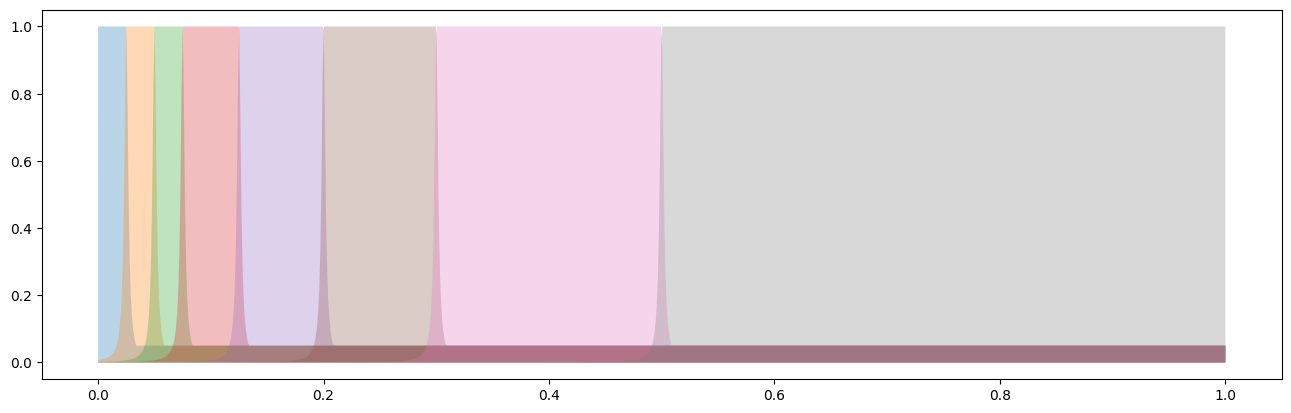

In [28]:
# @launchit.disable
t = lu.ScopedVars()
t.fig, t.ax = plt.subplots()
t.fig.set_figwidth(16)
t.X = np.linspace(0, 1, 1000)

for t.gm in LS.curriculum.game_modifs:
    t.Y = t.gm[0].edf(t.X)
    plt.fill_between(t.X, t.Y, alpha=0.3)

  0%|          | 0/100 [00:00<?, ?it/s]

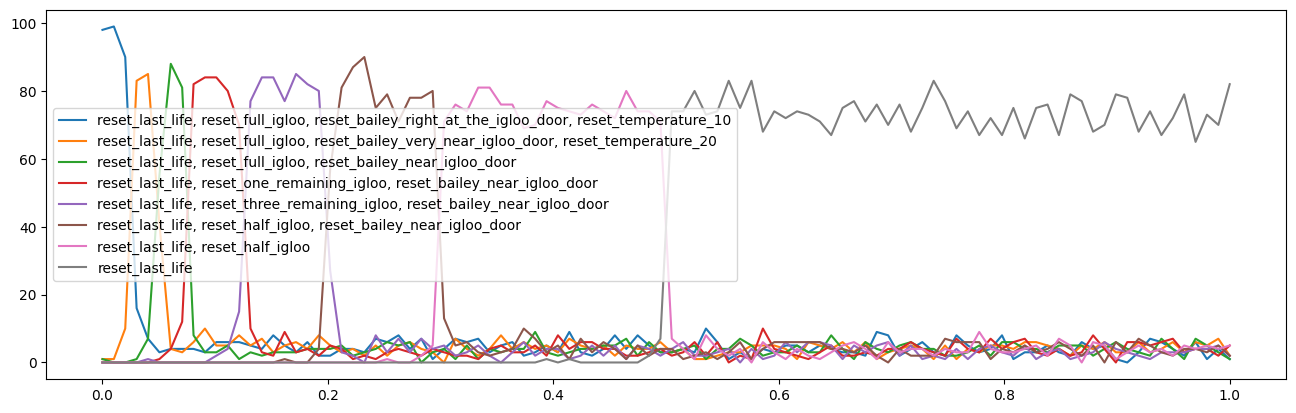

In [29]:
# @launchit.disable
t = lu.ScopedVars()
t.times = np.linspace(0, 1, 100)
t.game_modifs_counters = defaultdict(lambda: np.zeros(len(t.times), dtype=np.int32))

for _ in tqdm(range(100)):
    for t.t_ind, t.t in enumerate(t.times):
        t.game_modifs = LS.curriculum.get_plan_item(t.t).game_modifs
        t.game_modifs = tuple(t.game_modifs)
        t.game_modifs_counters[t.game_modifs][t.t_ind] += 1

t.fig, t.ax = plt.subplots()
t.fig.set_figwidth(16)

for t.game_modifs, t.counters in t.game_modifs_counters.items():
    t.ax.plot(t.times, t.counters, label=', '.join(t.game_modifs))

t.ax.legend();

## Upload

In [30]:
# @launchit.disable_2
import nbformat

def get_cell_source_by_tag(tag_name):
    with open(CONFIG.self_fname, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)
    
    for cell in nb.cells:
        if 'tags' in cell.metadata and tag_name in cell.metadata['tags']:
            return cell.source
    
    return None

In [31]:
# @launchit.disable_2
curriculum_tag_name = 'curriculum'
curriculum_source_code = get_cell_source_by_tag(curriculum_tag_name)
assert curriculum_source_code is not None, f'Failed to locate cell tagged \"{curriculum_tag_name}\"'
summary_writer.add_text('curriculum/source', f"```python\n{curriculum_source_code}\n```", 0)
summary_writer.flush()

# Dataset

## Dataset

In [32]:
@dataclass(slots=True)
class Dataset:
    # Metadata
    sequence_length: int = None
    prologue_size: int = None
    
    # Agent's input data
    obs: object = None
    obs_pmasks: object = None # padding masks
    
    # Agent's output data
    actions: object = None
    action_log_probs: object = None
    values: object = None
    
    # Environment response
    next_obs: object = None # observation which agent received after stepping (used to learn predictions)
    advantages: object = None
    returns: object = None
    
    # Debug
    debug_w_obs: object = None
    debug_w_values: object = None
    debug_dones: object = None

    shared_tensors: dict = None
    
    # Iteration support
    valid_inds: object = None
    batch_size: int = None
    is_shuffled: bool = None
    is_ptf: bool = None
    iter_inds: object = None
    iter_pos: int = None
    flattened: tuple = None
    selected: tuple = None
    bw_inds_stem: object = None

    Batch = namedtuple('Batch', 'obs, obs_pmasks, actions, action_log_probs, values, next_obs, advantages, returns, b_inds')
    
    def __init__(
        self,
        envs_count, 
        observation_space_shape, 
        rollout_steps_count, 
        sequence_length,
        batches_count,
        is_shuffled,
        is_ptf, # parallel teacher forcing, when enabled then all data items are returned as sequences, otherwise - just solo 
        is_next_obs,
        is_debug=False,
    ):
        self.sequence_length = sequence_length
        self.prologue_size = (sequence_length - 1)
        rollout_buf_size = self.prologue_size + rollout_steps_count # prologue (mem window from prev rollout) + actual rollout data
        assert rollout_buf_size > 0
        
        # Agent's input data
        self.obs = torch.zeros((envs_count, rollout_buf_size, *observation_space_shape)).to(CONFIG.cuda_device)
        self.obs_pmasks = torch.zeros((envs_count, rollout_buf_size, sequence_length)).to(CONFIG.cuda_device) 

        # Agent's output data
        self.actions = torch.zeros((envs_count, rollout_buf_size), dtype=torch.long).to(CONFIG.cuda_device)
        self.action_log_probs = torch.zeros((envs_count, rollout_buf_size)).to(CONFIG.cuda_device)
        self.values = torch.zeros((envs_count, rollout_buf_size)).to(CONFIG.cuda_device)

        # Environment response
        self.next_obs = lu.when(is_next_obs, lambda: torch.zeros((envs_count, rollout_buf_size, *observation_space_shape)).to(CONFIG.cuda_device), None)
        self.advantages = torch.zeros((envs_count, rollout_buf_size)).to(CONFIG.cuda_device)
        self.returns = torch.zeros((envs_count, rollout_buf_size)).to(CONFIG.cuda_device)

        # Debug
        self.debug_w_obs = lu.when(is_debug, lambda: torch.zeros((envs_count, rollout_buf_size, sequence_length, *observation_space_shape)).to(CONFIG.cuda_device), None)
        self.debug_w_values = lu.when(is_debug, lambda: torch.zeros((envs_count, rollout_buf_size, sequence_length)).to(CONFIG.cuda_device), None)
        self.debug_dones = lu.when(is_debug, lambda: torch.zeros((envs_count, rollout_buf_size)), None)
    
        self.shared_tensors = dict(
            obs=self.obs,
            obs_pmasks=self.obs_pmasks,
            actions=self.actions,
            action_log_probs=self.action_log_probs,
            values=self.values,
            next_obs=self.next_obs,
            advantages=self.advantages,
            returns=self.returns,
            debug_w_obs=self.debug_w_obs,
            debug_w_values=self.debug_w_values,
            debug_dones=self.debug_dones,
        )
        
        for t in self.shared_tensors.values():
            if t is not None:
                t.share_memory_()

        # Iteration support
        valid_inds = []
        
        for env_ind in range(envs_count):
            offset = env_ind * rollout_buf_size + self.prologue_size
            indices_for_env = offset + torch.arange(rollout_steps_count)
            valid_inds.append(indices_for_env)
            
        self.valid_inds = torch.cat(valid_inds).to(CONFIG.cuda_device)
        assert envs_count * rollout_steps_count % batches_count == 0, f'Not whole number of batches for given rollout data size: {((envs_count * rollout_steps_count) / batches_count)=}'
        self.batch_size = envs_count * rollout_steps_count // batches_count
        self.is_shuffled = is_shuffled
        self.is_ptf = is_ptf

        self.flattened = Dataset.Batch(
            obs=self.obs.view(-1, *self.obs.shape[2:]),
            obs_pmasks=self.obs_pmasks.view(-1, *self.obs_pmasks.shape[2:]),
            actions=self.actions.view(-1, *self.actions.shape[2:]),
            action_log_probs=self.action_log_probs.view(-1, *self.action_log_probs.shape[2:]),
            values=self.values.view(-1, *self.values.shape[2:]),
            next_obs=lu.when(is_next_obs, lambda: self.next_obs.view(-1, *self.next_obs.shape[2:]), None),
            advantages=self.advantages.view(-1, *self.advantages.shape[2:]),
            returns=self.returns.view(-1, *self.returns.shape[2:]),
            b_inds=None,
        )
        
        if self.is_ptf:
            self.selected = Dataset.Batch(
                obs=torch.zeros((self.batch_size * sequence_length, *observation_space_shape)).to(CONFIG.cuda_device),
                obs_pmasks=torch.ones((self.batch_size, sequence_length)).to(CONFIG.cuda_device), # obs_pmasks is the only shared tensor which is stored as is
                actions=torch.zeros((self.batch_size * sequence_length), dtype=torch.long).to(CONFIG.cuda_device),
                action_log_probs=torch.zeros((self.batch_size * sequence_length)).to(CONFIG.cuda_device),
                values=torch.zeros((self.batch_size * sequence_length)).to(CONFIG.cuda_device),
                next_obs=lu.when(is_next_obs, lambda: torch.zeros((self.batch_size * sequence_length, *observation_space_shape)).to(CONFIG.cuda_device), None),
                advantages=torch.zeros((self.batch_size * sequence_length)).to(CONFIG.cuda_device),
                returns=torch.zeros((self.batch_size * sequence_length)).to(CONFIG.cuda_device),
                b_inds=None,
            )
        else:
            self.selected = Dataset.Batch(
                obs=torch.zeros((self.batch_size * sequence_length, *observation_space_shape)).to(CONFIG.cuda_device),
                obs_pmasks=torch.ones((self.batch_size, sequence_length)).to(CONFIG.cuda_device), # obs_pmasks is the only shared tensor which is stored as is
                actions=torch.zeros(self.batch_size, dtype=torch.long).to(CONFIG.cuda_device),
                action_log_probs=torch.zeros(self.batch_size).to(CONFIG.cuda_device),
                values=torch.zeros(self.batch_size).to(CONFIG.cuda_device),
                next_obs=lu.when(is_next_obs, lambda: torch.zeros((self.batch_size, *observation_space_shape)).to(CONFIG.cuda_device), None),
                advantages=torch.zeros(self.batch_size).to(CONFIG.cuda_device),
                returns=torch.zeros(self.batch_size).to(CONFIG.cuda_device),
                b_inds=None,
            )
            
        self.bw_inds_stem = torch.arange(-sequence_length + 1, 1).to(CONFIG.cuda_device)
        self.bw_inds_stem = self.bw_inds_stem.unsqueeze(0).expand(self.batch_size, self.bw_inds_stem.shape[0])

    def __iter__(self):
        if self.is_shuffled:
            valids_inds_order = torch.randperm(len(self.valid_inds), device=CONFIG.cuda_device)
            self.iter_inds = self.valid_inds[valids_inds_order]
        else:
            self.iter_inds = self.valid_inds

        self.iter_pos = 0
        return self
    
    def __next__(self):
        if self.iter_pos >= len(self.iter_inds):
            raise StopIteration

        b_inds = self.iter_inds[self.iter_pos:self.iter_pos+self.batch_size]
        self.iter_pos += self.batch_size
        
        torch.gather(input=self.flattened.obs_pmasks, index=b_inds.unsqueeze(1).expand((-1, self.sequence_length)), dim=0, out=self.selected.obs_pmasks)
        
        bw_inds = self.bw_inds_stem + b_inds.unsqueeze(1) # batch-window indices, shape: [batch, seq_len]
        bw_inds = bw_inds.view(-1)
        
        torch.index_select(input=self.flattened.obs, index=bw_inds, dim=0, out=self.selected.obs)

        if self.is_ptf:
            torch.index_select(input=self.flattened.actions, index=bw_inds, dim=0, out=self.selected.actions)
            torch.index_select(input=self.flattened.action_log_probs, index=bw_inds, dim=0, out=self.selected.action_log_probs)
            torch.index_select(input=self.flattened.values, index=bw_inds, dim=0, out=self.selected.values)
            torch.index_select(input=self.flattened.advantages, index=bw_inds, dim=0, out=self.selected.advantages)
            torch.index_select(input=self.flattened.returns, index=bw_inds, dim=0, out=self.selected.returns)

            if self.next_obs is not None:
                torch.index_select(input=self.flattened.next_obs, index=bw_inds, dim=0, out=self.selected.next_obs)
                next_obs = self.selected.next_obs.view((self.batch_size, self.sequence_length, *self.selected.next_obs.shape[1:]))
            else:
                next_obs = None
            
            return Dataset.Batch(
                obs=self.selected.obs.view((self.batch_size, self.sequence_length, *self.selected.obs.shape[1:])),
                obs_pmasks=self.selected.obs_pmasks,
                actions=self.selected.actions.view((self.batch_size, self.sequence_length, *self.selected.actions.shape[1:])),
                action_log_probs=self.selected.action_log_probs.view((self.batch_size, self.sequence_length, *self.selected.action_log_probs.shape[1:])),
                values=self.selected.values.view((self.batch_size, self.sequence_length, *self.selected.values.shape[1:])),
                next_obs=next_obs,
                advantages=self.selected.advantages.view((self.batch_size, self.sequence_length, *self.selected.advantages.shape[1:])),
                returns=self.selected.returns.view((self.batch_size, self.sequence_length, *self.selected.returns.shape[1:])),
                b_inds=b_inds,
            )
        else:
            torch.index_select(input=self.flattened.actions, index=b_inds, dim=0, out=self.selected.actions)
            torch.index_select(input=self.flattened.action_log_probs, index=b_inds, dim=0, out=self.selected.action_log_probs)
            torch.index_select(input=self.flattened.values, index=b_inds, dim=0, out=self.selected.values)
            torch.index_select(input=self.flattened.advantages, index=b_inds, dim=0, out=self.selected.advantages)
            torch.index_select(input=self.flattened.returns, index=b_inds, dim=0, out=self.selected.returns)

            if self.next_obs is not None:
                torch.index_select(input=self.flattened.next_obs, index=b_inds, dim=0, out=self.selected.next_obs)
                next_obs = self.selected.next_obs
            else:
                next_obs = None
            
            return Dataset.Batch(
                obs=self.selected.obs.view((self.batch_size, self.sequence_length, *self.selected.obs.shape[1:])),
                obs_pmasks=self.selected.obs_pmasks,
                actions=self.selected.actions,
                action_log_probs=self.selected.action_log_probs,
                values=self.selected.values,
                next_obs=next_obs,
                advantages=self.selected.advantages,
                returns=self.selected.returns,
                b_inds=b_inds,
            )

## Test

### Smoke test

In [33]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 8
t.rollout_steps_count = 64
t.sequence_length = 16
t.dataset = Dataset(
    envs_count=t.envs_count,
    observation_space_shape=LS.agent.params.observation_space_shape, 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=t.sequence_length, 
    batches_count=2,
    is_shuffled=False,
    is_ptf=False,
    is_next_obs=True,
    is_debug=True,
)

for t.name, t.v in t.dataset.shared_tensors.items():
    if t.v is not None:
        assert t.v.is_shared(), f'{t.name} is not shared'
        LOG(f'{t.name:>28}: {str(t.v.device):>6}, {str(t.v.dtype):>15}, {t.v.shape}')

assert len(t.dataset.valid_inds) == (t.envs_count * t.rollout_steps_count)
assert len(t.dataset.valid_inds.unique()) == (t.envs_count * t.rollout_steps_count)

t.prev_env_valid_inds = None

for t.env_ind in range(t.envs_count):
    t.prev_env_training_ind = lu.when(t.prev_env_valid_inds is not None, lambda: t.prev_env_valid_inds[-1] + 1, 0)
    t.env_valid_inds = t.prev_env_training_ind + (t.sequence_length - 1) + torch.arange(t.rollout_steps_count).to(CONFIG.cuda_device)
    assert torch.all(t.env_valid_inds == t.dataset.valid_inds[t.env_ind*t.rollout_steps_count:(t.env_ind+1)*t.rollout_steps_count])
    t.prev_env_valid_inds = t.env_valid_inds

                         obs:    cpu,   torch.float32, torch.Size([8, 79, 1, 84, 84])
                  obs_pmasks:    cpu,   torch.float32, torch.Size([8, 79, 16])
                     actions:    cpu,     torch.int64, torch.Size([8, 79])
            action_log_probs:    cpu,   torch.float32, torch.Size([8, 79])
                      values:    cpu,   torch.float32, torch.Size([8, 79])
                    next_obs:    cpu,   torch.float32, torch.Size([8, 79, 1, 84, 84])
                  advantages:    cpu,   torch.float32, torch.Size([8, 79])
                     returns:    cpu,   torch.float32, torch.Size([8, 79])
                 debug_w_obs:    cpu,   torch.float32, torch.Size([8, 79, 16, 1, 84, 84])
              debug_w_values:    cpu,   torch.float32, torch.Size([8, 79, 16])
                 debug_dones:    cpu,   torch.float32, torch.Size([8, 79])


### Iteration

In [34]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 32
t.rollout_steps_count = 128
t.sequence_length = 16
t.dataset = Dataset(
    envs_count=t.envs_count,
    observation_space_shape=LS.agent.params.observation_space_shape, 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=t.sequence_length, 
    batches_count=4,
    is_shuffled=True,
    is_ptf=False,
    is_next_obs=True,
    is_debug=False,
)

for t.batch in t.dataset:
    pass

for t.fn in t.batch._fields:
    if getattr(t.batch, t.fn) is not None:
        LOG(f'{t.fn:>20}.shape={getattr(t.batch, t.fn).shape}')
    else:
        LOG(f'{t.fn:>20}=None')

                 obs.shape=torch.Size([1024, 16, 1, 84, 84])
          obs_pmasks.shape=torch.Size([1024, 16])
             actions.shape=torch.Size([1024])
    action_log_probs.shape=torch.Size([1024])
              values.shape=torch.Size([1024])
            next_obs.shape=torch.Size([1024, 1, 84, 84])
          advantages.shape=torch.Size([1024])
             returns.shape=torch.Size([1024])
              b_inds.shape=torch.Size([1024])


# Rollout

## RolloutManager

In [35]:
class RolloutManager:
    def __init__(self, agent, envs_count, rollout_steps_count, prologue_size, random_seed, game_modifs=None):
        self.agent = agent
        self.device = next(iter(agent.parameters())).device
        self.env_inds = torch.arange(envs_count)
        self.rollout_steps_count = rollout_steps_count
        self.prologue_size = prologue_size

        # Sliding windows
        obs_sequence_length = agent.params.obs_sequence_length
        self.w_obs = torch.zeros((envs_count, obs_sequence_length, *self.agent.params.observation_space_shape)).to(self.device)
        self.w_obs_pmasks = torch.ones((envs_count, obs_sequence_length)).to(self.device)
        self.w_values = torch.zeros((envs_count, obs_sequence_length)).to(self.device) # only for debug purposes
        self.w_actions_noises = self.agent.generate_actions_noise((envs_count, self.agent.params.action_plan_length)).to(self.device)
        
        # Rollout buffers (used only during current rollout, no data forwarding)
        self.r_rewards = torch.zeros((envs_count, self.rollout_steps_count))
        self.r_dones = torch.zeros((envs_count, self.rollout_steps_count))
        
        self.envs = create_envs(envs_count)
        LOG(f'Envs created, {envs_count=}')

        reset_modifs = self.get_reset_modifs(game_modifs, env_inds=self.env_inds)
        self.obs, _ = self.envs.reset(seed=random_seed, options=dict(reset_modifs=reset_modifs))
        self.obs = torch.tensor(self.obs, dtype=torch.float, device=self.device)
        self.obs = Agent.preprocess_obs(self.obs)
        self.w_obs[:,-1] = self.obs
        self.w_obs_pmasks[:,-1] = 0
        LOG('Envs reset')
        
    def rollout(self, shared_tensors, tau, game_modifs=None, with_timing_counters=False):
        out_obs, out_obs_pmasks, out_actions, out_action_log_probs, out_values = (
            shared_tensors['obs'],
            shared_tensors['obs_pmasks'],
            shared_tensors['actions'],
            shared_tensors['action_log_probs'],
            shared_tensors['values'],
        )
        out_next_obs, out_advantages, out_returns = (
            shared_tensors['next_obs'],
            shared_tensors['advantages'],
            shared_tensors['returns'],
        )
        # debug tensors
        out_debug_w_obs, out_debug_w_values, out_debug_dones = (
            shared_tensors['debug_w_obs'],
            shared_tensors['debug_w_values'],
            shared_tensors['debug_dones'],
        )
        assert self.rollout_steps_count + self.prologue_size == out_obs_pmasks.shape[1]
        
        # ROLLOUT
        ei0 = self.env_inds[0].item()
        ei1 = self.env_inds[-1].item() + 1

        assert torch.all(self.w_obs[:,-1] == self.obs)
        
        # fill prologues with data from the prev rollout
        out_obs[ei0:ei1,:self.prologue_size] = out_obs[ei0:ei1,-self.prologue_size:]
        out_obs_pmasks[ei0:ei1,:self.prologue_size] = out_obs_pmasks[ei0:ei1,-self.prologue_size:]
        out_actions[ei0:ei1,:self.prologue_size] = out_actions[ei0:ei1,-self.prologue_size:]
        out_action_log_probs[ei0:ei1,:self.prologue_size] = out_action_log_probs[ei0:ei1,-self.prologue_size:]
        out_values[ei0:ei1,:self.prologue_size] = out_values[ei0:ei1,-self.prologue_size:]
        out_advantages[ei0:ei1,:self.prologue_size] = out_advantages[ei0:ei1,-self.prologue_size:]
        out_returns[ei0:ei1,:self.prologue_size] = out_returns[ei0:ei1,-self.prologue_size:]

        if out_next_obs is not None:
            out_next_obs[ei0:ei1,:self.prologue_size] = out_next_obs[ei0:ei1,-self.prologue_size:]

        if out_debug_dones is not None:
            out_debug_dones[ei0:ei1,:self.prologue_size] = out_debug_dones[ei0:ei1,-self.prologue_size:]

        my_life_stats = []
        my_episode_stats = []
        my_timing_counters = defaultdict(list)

        def collect_stats(key, infos, stats):
            prefix = lu.when('life' in key, 'life', 'episode')
                
            for env_ind in np.argwhere(infos[key]).ravel():
                stats.append(dict(
                    env_ind=self.env_inds[env_ind].item(),
                    r=infos[prefix + '_returns'][env_ind],
                    l=infos[prefix + '_lengths'][env_ind],
                ))

        with torch.no_grad():
            for rollout_step in range(self.rollout_steps_count):
                t0 = time.time()
                
                out_index = self.prologue_size + rollout_step
                out_obs[ei0:ei1,out_index] = self.obs
                out_obs_pmasks[ei0:ei1,out_index] = self.w_obs_pmasks
                
                if out_debug_w_obs is not None:
                    out_debug_w_obs[ei0:ei1,out_index] = self.w_obs

                my_timing_counters['out_obs'].append(time.time() - t0)
                t0 = time.time()

                # Analyze observation windows
                agent_result = self.agent.get_action_and_value(
                    obs=self.w_obs, 
                    padding_masks=self.w_obs_pmasks,
                    actions_noise=self.w_actions_noises[:,0],
                    tau=tau,
                )

                out_actions[ei0:ei1,out_index] = agent_result.actions
                out_action_log_probs[ei0:ei1,out_index] = agent_result.action_log_probs
                out_values[ei0:ei1,out_index] = agent_result.values
                
                if out_debug_w_values is not None:
                    self.w_values = self.w_values.roll(shifts=-1, dims=1)
                    self.w_values[:,-1] = agent_result.values
                    out_debug_w_values[ei0:ei1,out_index] = self.w_values
                    
                my_timing_counters['get_action_and_value'].append(time.time() - t0)
                t0 = time.time()
                
                # Interact with environments
                self.obs, rewards, terminations, truncations, infos = self.envs.step(agent_result.actions.cpu().numpy().ravel())
                self.obs = torch.tensor(self.obs, dtype=torch.float, device=self.device)
                self.obs = Agent.preprocess_obs(self.obs)
                
                # Update sliding windows which are used to feed agent
                self.w_obs = self.w_obs.roll(shifts=-1, dims=1)
                self.w_obs[:,-1] = self.obs
                
                self.w_obs_pmasks = self.w_obs_pmasks.roll(shifts=-1, dims=1)
                self.w_obs_pmasks[:,-1] = 0

                self.w_actions_noises = self.w_actions_noises.roll(shifts=-1, dims=1)
                self.w_actions_noises[:,-1] = self.agent.generate_actions_noise(len(self.env_inds))

                if out_next_obs is not None:
                    out_next_obs[ei0:ei1,out_index] = self.obs
                    
                need_reset_envs = np.logical_or(terminations, truncations)
                dones = need_reset_envs.copy()

                if HP.env.is_episodic_life and np.any(infos['is_life_lost']):
                    # Manually trigger done flag and truncate observations window (i.e. leave only current observation for new life)
                    # for envs which hit life loss
                    life_lost_envs = infos['is_life_lost']
                    self.w_obs_pmasks[life_lost_envs] = 1
                    self.w_obs_pmasks[life_lost_envs,-1] = 0
                    dones[life_lost_envs] = True
                
                self.r_dones[:,rollout_step] = torch.tensor(dones, dtype=torch.float)
                self.r_rewards[:,rollout_step] = torch.tensor(rewards, dtype=torch.float)
                
                if out_debug_dones is not None:
                    out_debug_dones[ei0:ei1,out_index] = torch.tensor(dones, dtype=torch.float)
                
                collect_stats('is_life_lost', infos, my_life_stats)
                collect_stats('is_episode_over', infos, my_episode_stats)
                my_timing_counters['env.step'].append(time.time() - t0)
        
                # Reset envs which hit an episode end or are truncated manually, for resetted envs get new observations
                if np.any(need_reset_envs):
                    t00 = time.time()
                    reset_modifs = self.get_reset_modifs(game_modifs, env_inds=np.argwhere(need_reset_envs).ravel())
                    assert len(reset_modifs) == 0 or len(reset_modifs) == need_reset_envs.sum(), (reset_modifs, need_reset_envs)
                    reset_obs, _ = self.envs.reset(options=dict(reset_mask=need_reset_envs, reset_modifs=reset_modifs))
                    reset_obs = torch.tensor(reset_obs[need_reset_envs], dtype=torch.float).to(self.device)
                    reset_obs = Agent.preprocess_obs(reset_obs)
                    self.obs[need_reset_envs] = reset_obs
                    self.w_obs[:,-1] = self.obs
                    self.w_obs_pmasks[need_reset_envs] = 1
                    self.w_obs_pmasks[need_reset_envs,-1] = 0
                    my_timing_counters['env.reset'].append(time.time() - t00)

        t0 = time.time()
        # ADVANTAGES
        with torch.no_grad():
            # Look ahead for one step
            next_values = self.agent.get_value(
                obs=self.w_obs,
                padding_masks=self.w_obs_pmasks,
            )
            my_rewards = self.r_rewards.to(self.device, non_blocking=True)
            my_dones = self.r_dones.to(self.device, non_blocking=True)
            my_values = out_values[ei0:ei1,-self.rollout_steps_count:]
            my_advantages = torch.zeros_like(out_advantages[ei0:ei1,-self.rollout_steps_count:])
            assert my_rewards.shape[1] == self.rollout_steps_count
            assert my_dones.shape[1] == self.rollout_steps_count
            assert my_values.shape[1] == self.rollout_steps_count
            assert my_advantages.shape[1] == self.rollout_steps_count
            lastgaelam = 0
            
            for t in reversed(range(self.rollout_steps_count)):
                if t == self.rollout_steps_count - 1:
                    nextnonterminal = 1.0 - my_dones[:,t]
                    nextnonterminal = nextnonterminal.to(self.device, non_blocking=True)
                    nextvalues = next_values
                else:
                    nextnonterminal = 1.0 - my_dones[:,t]
                    nextvalues = my_values[:,t+1]
                
                delta = my_rewards[:,t] + HP.ppo.gamma * nextvalues * nextnonterminal - my_values[:,t]
                lastgaelam = delta + HP.ppo.gamma * HP.ppo.gae_lambda * nextnonterminal * lastgaelam
                my_advantages[:,t] = lastgaelam

            out_advantages[ei0:ei1,-self.rollout_steps_count:] = my_advantages
            out_returns[ei0:ei1,-self.rollout_steps_count:] = my_advantages + out_values[ei0:ei1,-self.rollout_steps_count:]

        my_timing_counters['advantages'].append(time.time() - t0)

        return dict(
            life_stats=my_life_stats,
            episode_stats=my_episode_stats,
            timing_counters=lu.when(with_timing_counters, my_timing_counters, None),
        )

    def get_reset_modifs(self, game_modifs, env_inds):
        if game_modifs is None:
            return {}
            
        return dict(map(lambda i: (i.item(), lu.coalesce(game_modifs, [])), env_inds))

## Test

### rollout: performance

In [36]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = lu.when(CONFIG.is_cuda, 32, 8)
t.timing_counters = defaultdict(list)
t.rollout_steps_count = 128
t.dataset = Dataset(
    envs_count=t.envs_count,
    observation_space_shape=LS.agent.params.observation_space_shape, 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=HP.agent.obs_sequence_length, 
    batches_count=4,
    is_shuffled=True,
    is_ptf=False,
    is_next_obs=True,
    is_debug=False,
)
t.rm = RolloutManager(
    agent=LS.agent, 
    envs_count=t.envs_count, 
    rollout_steps_count=t.rollout_steps_count, 
    prologue_size=t.dataset.prologue_size,
    random_seed=HP.system.random_seed,
)

t.global_steps_count = t.rollout_steps_count * t.envs_count * 10
t.step = 0

with tqdm(total=t.global_steps_count) as pbar:
    while t.step < t.global_steps_count:
        t.rr = t.rm.rollout(t.dataset.shared_tensors, tau=0.1, with_timing_counters=True)

        for t.timing_counter_key, t.timing_counter_times in t.rr['timing_counters'].items():
            t.timing_counters[t.timing_counter_key].extend(t.timing_counter_times)

        step_inc = t.rollout_steps_count * t.envs_count
        t.step += step_inc
        pbar.update(step_inc)

list(map(lambda kv: (kv[0], np.array(kv[1]).mean().item()), t.timing_counters.items()))

Envs created, envs_count=8
Envs reset


  0%|          | 0/10240 [00:00<?, ?it/s]

[('out_obs', 3.613270819187164e-05),
 ('get_action_and_value', 0.015589188784360886),
 ('env.step', 0.0034067172557115553),
 ('advantages', 0.022485566139221192),
 ('env.reset', 0.010613398118452593)]

### rollout: obs, pmasks, values

In [37]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = lu.when(CONFIG.is_cuda, 32, 8)
t.df_columns = defaultdict(list)
t.all_life_stats_items = []
t.all_episode_stats_items = []
t.rollout_steps_count = 128
t.dataset = Dataset(
    envs_count=t.envs_count,
    observation_space_shape=LS.agent.params.observation_space_shape, 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=HP.agent.obs_sequence_length, 
    batches_count=4,
    is_shuffled=False,
    is_ptf=True,
    is_next_obs=True,
    is_debug=True,
)
t.rm = RolloutManager(
    agent=LS.agent, 
    envs_count=t.envs_count, 
    rollout_steps_count=t.rollout_steps_count, 
    prologue_size=t.dataset.prologue_size,
    random_seed=HP.system.random_seed,
)

t.global_steps_count = t.rollout_steps_count * t.envs_count * 5
t.step = 0

with tqdm(total=t.global_steps_count) as pbar:
    while t.step < t.global_steps_count:
        t.stats_afs = dict(
            life_stats=dict(l=RecursiveAverageFilter(), r=RecursiveAverageFilter()),
            episode_stats=dict(l=RecursiveAverageFilter(), r=RecursiveAverageFilter()),
        )

        t.rr = t.rm.rollout(t.dataset.shared_tensors, tau=0.1)

        for t.k in t.stats_afs:
            for t.stats_item in t.rr[t.k]:
                t.stats_afs[t.k]['l'](t.stats_item['l'])
                t.stats_afs[t.k]['r'](t.stats_item['r'])

                if t.k == 'episode_stats':
                    t.all_episode_stats_items.append(t.stats_item['r'])

                if t.k == 'life_stats':
                    t.all_life_stats_items.append(t.stats_item['r'])

        t.obs_pmasks = t.dataset.obs_pmasks.view(-1, *t.dataset.obs_pmasks.shape[2:])
        t.debug_w_obs = t.dataset.debug_w_obs.view(-1, *t.dataset.debug_w_obs.shape[2:])
        t.debug_w_values = t.dataset.debug_w_values.view(-1, *t.dataset.debug_w_values.shape[2:])

        # Verify that we get exactly the same windows (obs, obs_pmasks, values, ...) as during rollout
        for t.batch in t.dataset:
            assert torch.all(t.obs_pmasks[t.batch.b_inds] == t.batch.obs_pmasks)
            assert torch.all(t.batch.obs_pmasks[:,-1] == 0) # current items are last items, make sure obs_pmasks reflects this fact
            
            t.b_orig_w_obs = t.debug_w_obs[t.batch.b_inds]
            assert torch.all(t.b_orig_w_obs == t.batch.obs)
                
            t.b_orig_w_values = t.debug_w_values[t.batch.b_inds]
            assert torch.all(t.b_orig_w_values == t.batch.values)
            
        step_inc = t.rollout_steps_count * t.envs_count
        t.step += step_inc
        pbar.update(step_inc)

        t.df_columns['life_stats.r'].append(t.stats_afs['life_stats']['r'].v)
        t.df_columns['life_stats.l'].append(t.stats_afs['life_stats']['l'].v)
        t.df_columns['life_stats.n'].append(t.stats_afs['life_stats']['l'].n)
        t.df_columns['episode_stats.r'].append(t.stats_afs['episode_stats']['r'].v)
        t.df_columns['episode_stats.l'].append(t.stats_afs['episode_stats']['l'].v)
        t.df_columns['episode_stats.n'].append(t.stats_afs['episode_stats']['l'].n)

pd.DataFrame(t.df_columns).style.format("{:.2f}")

Envs created, envs_count=8
Envs reset


  0%|          | 0/5120 [00:00<?, ?it/s]

,life_stats.r,life_stats.l,life_stats.n,episode_stats.r,episode_stats.l,episode_stats.n
0,0.00,303.00,1.00,0.00,0.00,0.00
1,10.00,793.00,5.00,0.00,0.00,0.00
2,10.00,1038.00,4.00,0.00,0.00,0.00
3,10.00,712.57,7.00,0.00,0.00,0.00
4,8.00,583.60,5.00,40.00,2523.00,1.00


### rollout: next_obs

In [38]:
# @launchit.disable
t = lu.ScopedVars()
t.rollout_steps_count = 128
t.dataset = Dataset(
    envs_count=1,
    observation_space_shape=LS.agent.params.observation_space_shape, 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=HP.agent.obs_sequence_length, 
    batches_count=1,
    is_shuffled=False,
    is_ptf=True,
    is_next_obs=True,
    is_debug=True,
)
t.rm = RolloutManager(
    agent=LS.agent, 
    envs_count=1, 
    rollout_steps_count=t.rollout_steps_count, 
    prologue_size=t.dataset.prologue_size,
    random_seed=HP.system.random_seed,
)
    
t.global_steps_count = t.rollout_steps_count * 5
t.step = 0

with tqdm(total=t.global_steps_count) as pbar:
    while t.step < t.global_steps_count:
        t.rr = t.rm.rollout(t.dataset.shared_tensors, tau=0.1)

        t.debug_dones = t.dataset.debug_dones.view(-1, *t.dataset.debug_dones.shape[2:]).to(CONFIG.cuda_device)

        for t.batch in t.dataset:
            # Internal check: verify that within window items which are not terminal and which are present (obs_pmasks) have matching next obs
            t.bw_inds = t.dataset.bw_inds_stem + t.batch.b_inds.unsqueeze(1)
            t.bw_inds = t.bw_inds.view(-1)
            t.bw_dones = t.debug_dones[t.bw_inds].view(t.batch.obs.shape[:2])

            for t.i in range(t.bw_dones.shape[0]):
                for t.j in range(t.bw_dones.shape[1] - 1):
                    if t.bw_dones[t.i,t.j] == 0 and t.batch.obs_pmasks[t.i,t.j] == 0:
                        assert torch.all(t.batch.obs[t.i,t.j+1] == t.batch.next_obs[t.i,t.j])
            
            # External check: verify that all running (non terminal) items must have next item where obs == next_obs
            t.running = ~t.debug_dones[t.batch.b_inds].bool()
            
            for i, is_running in enumerate(t.running):
                if is_running and (i + 1) < len(t.batch.obs):
                    assert torch.all(t.batch.obs[i+1,-1] == t.batch.next_obs[i,-1])
            
        step_inc = t.rollout_steps_count
        t.step += step_inc
        pbar.update(step_inc)

Envs created, envs_count=1
Envs reset


  0%|          | 0/640 [00:00<?, ?it/s]

# Worker

Implementation details regarding memory sharing between PyTorch applications: <a href="./dialogs/torch-multiprocessing-shm.ipynb">torch-multiprocessing-shm.ipynb</a>

## WorkerTask

In [39]:
# Exchange data between main and child processes
@dataclass(slots=True)
class WorkerTask:
    task_id: int
    op: str
    params: dict = None

@dataclass(slots=True)
class WorkerTaskResult:
    task_id: int
    payload: object = None

## WorkerCtl

In [40]:
# Master's stuff (main process)
class WorkerCtl:
    task_id = 0
    
    def __init__(self, worker_ind, module, mp_ctx):
        self.task_ctor = getattr(module, 'WorkerTask')
        self.worker_ind = worker_ind
        self.task_queue = mp_ctx.Queue()
        self.task_result_queue = mp_ctx.Queue()
        self.process = mp_ctx.Process(target=getattr(module, 'worker_loop'), args=(worker_ind, self.task_queue, self.task_result_queue))
        self.process.start()
        self.pending_task_ids = deque()

    @staticmethod
    def gen_task_id():
        WorkerCtl.task_id += 1
        return WorkerCtl.task_id

    def healthcheck(self):
        task = self.task_ctor(task_id=self.gen_task_id(), op='HEALTHCHECK')
        self.task_queue.put(task)
        self.task_result_queue.get()
        
    def terminate(self, timeout=None):
        if self.process.is_alive():
            task = self.task_ctor(task_id=self.gen_task_id(), op='TERMINATE')
            try:
                self.task_queue.put(task)
                self.task_result_queue.get(timeout=timeout)
                self.process.join()
            except:
                self.process.terminate()

    def set_num_threads(self, n):
        task = self.task_ctor(
            task_id=self.gen_task_id(), 
            op='SET_NUM_THREADS', 
            params=dict(n=n),
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def init_agent(self, agent_params, agent_state_dict=None, torch_compile=False, device=None):
        if agent_state_dict is not None:
            for key in agent_state_dict:
                assert agent_state_dict[key].is_shared()
        
        task = self.task_ctor(
            task_id=self.gen_task_id(), 
            op='INIT_AGENT', 
            params=dict(
                agent_params=dataclasses.asdict(agent_params),
                agent_state_dict=agent_state_dict,
                torch_compile=torch_compile,
                device=device,
            ),
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def sync_agent(self, agent_state_dict):
        for key in agent_state_dict:
            assert agent_state_dict[key].is_shared()
                
        task = self.task_ctor(
            task_id=self.gen_task_id(),
            op='SYNC_AGENT',
            params=dict(agent_state_dict=agent_state_dict),
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def init_rollout(self, env_inds, rollout_steps_count, prologue_size):
        task = self.task_ctor(
            task_id=self.gen_task_id(), 
            op='INIT_ROLLOUT', 
            params=dict(
                env_inds=env_inds,
                rollout_steps_count=rollout_steps_count,
                prologue_size=prologue_size,
            )
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id
        
    def rollout(self, shared_tensors, with_timing_counters=False):
        for k, t in shared_tensors.items():
            if t is not None:
                assert t.is_shared(), f'Tensor {k} is not shared'
            
        task = self.task_ctor(
            task_id=self.gen_task_id(), 
            op='ROLLOUT', 
            params=dict(
                shared_tensors=shared_tensors,
                with_timing_counters=with_timing_counters,
            ), 
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def capture_video_of_test_rollout(self, max_steps_count, video_file_name, random_seed=None, game_modifs_list=None, forward_data=None):
        task = self.task_ctor(
            task_id=self.gen_task_id(),
            op='CAPTURE_VIDEO',
            params=dict(
                max_steps_count=max_steps_count, 
                video_file_name=video_file_name,
                random_seed=random_seed,
                game_modifs_list=game_modifs_list,
                forward_data=forward_data,
            ),
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def is_busy(self):
        return len(self.pending_task_ids) > 0
    
    def get_task_result(self):
        assert len(self.pending_task_ids) > 0
        result = self.task_result_queue.get()
        assert result.task_id == self.pending_task_ids.popleft()
        return result

    def peek_task_result(self):
        if not self.pending_task_ids:
            return None
        
        try:
            result = self.task_result_queue.get(block=False)
            assert result.task_id == self.pending_task_ids.popleft()
            return result
        except queue.Empty:
            return None # task is not completed yet

    def drain_task_results(self):
        results = []

        while self.pending_task_ids:
            task_id = self.pending_task_ids.popleft()
            task_result = self.task_result_queue.get()
            assert task_result.task_id == task_id
            results.append(task_result)

        return results

## worker_loop

In [41]:
# Executed in child process
def worker_loop(worker_ind, task_queue, task_result_queue):
    @dataclass(slots=True)
    class WorkerState:
        agent: object = None
        is_attached_agent: bool = False
        rollout_manager: object = None
    
    CONFIG = create_config()
    global LOG # push to global so it's available to RolloutManager
    LOG = Logging.get()
    LOG.app_name = CONFIG.self_name
    LOG.enable('syslog', True)
    LOG.enable('stdout', False)
    worker_random_seed = HP.system.random_seed + worker_ind

    with LOG.auto_prefix('WRK', worker_ind, 'SEED', worker_random_seed):
        LOG(f'CONFIG={CONFIG._asdict()}')
        
        au.init()
        random.seed(worker_random_seed)
        torch.manual_seed(worker_random_seed)
        RNG = np.random.default_rng(worker_random_seed)
        LOG(f'{worker_random_seed=}')
        
        torch.backends.cudnn.deterministic = HP.system.is_torch_deterministic
        LOG(f'{torch.backends.cudnn.deterministic=}')

        WS = WorkerState()
        LOG('Worker is ready')
        
        task_wait_timeout = 60
        is_running = True
    
        while is_running:
            try:
                # task is expected to be an instanace of WorkerTask class
                task = task_queue.get(block=True, timeout=task_wait_timeout)
            except queue.Empty:
                LOG(f'Didn\'t get any tasks within {task_wait_timeout} seconds, waiting again')
                continue

            with LOG.auto_prefix('TASK', task.task_id):
                LOG(f'Got task #{task.task_id} {task.op}')
                task_result = WorkerTaskResult(task_id=task.task_id)
                
                match task.op:
                    case 'HEALTHCHECK':
                        pass
                    case 'TERMINATE':
                        is_running = False
                    case 'SET_NUM_THREADS':
                        torch.set_num_threads(task.params['n'])
                    case 'INIT_AGENT':
                        ap = Agent.Params(**task.params['agent_params'])
                        device = lu.coalesce(task.params.get('device'), CONFIG.cuda_device)
                        WS.agent = Agent(ap).to(device)
                        
                        if task.params['torch_compile']:
                            WS.agent = torch.compile(WS.agent, fullgraph=True)
                            LOG('Agent compiled')
                            
                        WS.is_attached_agent = task.params['agent_state_dict'] is not None
                        
                        if WS.is_attached_agent:
                            # Storage for weights of attached agent is pointed to agent's weights in main process
                            state_dict = task.params['agent_state_dict']
                            
                            with torch.no_grad():
                                for name, param in WS.agent.named_parameters():
                                    assert state_dict[name].is_shared()
                                    param.data = state_dict[name]

                        LOG(f'{WS.is_attached_agent=}')
                    case 'SYNC_AGENT':
                        assert WS.agent is not None
                        assert not WS.is_attached_agent
                        
                        state_dict = task.params['agent_state_dict']
                        
                        with torch.no_grad():
                            # Fast GPU-TO-GPU sync
                            for name, param in WS.agent.named_parameters():
                                assert state_dict[name].is_shared()
                                param.copy_(state_dict[name])
                    case 'INIT_ROLLOUT':
                        assert WS.agent is not None
                        WS.rollout_manager = RolloutManager(
                            WS.agent, 
                            env_inds=task.params['env_inds'], 
                            rollout_steps_count=task.params['rollout_steps_count'], 
                            prologue_size=task.params['prologue_size'],
                            random_seed=worker_random_seed,
                        )
                    case 'ROLLOUT':
                        assert WS.agent is not None
                        assert WS.rollout_manager is not None
                        task_result.payload = WS.rollout_manager.rollout(task.params['shared_tensors'], task.params['with_timing_counters'])
                        LOG(f'Done rollout for {WS.rollout_manager.rollout_steps_count} steps')    
                    case 'CAPTURE_VIDEO':
                        assert WS.agent is not None
                        LOG(f'Starting video capture: {task.params=}')
                        with torch.no_grad():
                            video_file_name, video_meta = capture_video_of_test_rollout(
                                WS.agent, 
                                max_steps_count=task.params['max_steps_count'], 
                                video_file_name=task.params['video_file_name'],
                                random_seed=task.params['random_seed'],
                                game_modifs_list=task.params['game_modifs_list'],
                            )
                            task_result.payload = (video_file_name, video_meta, task.params['forward_data'])
                    case _:
                        LOG(f'Unknown {task.op=}, ignoring')
        
                task_result_queue.put(task_result)
                LOG('Task complete')
        
        LOG('Worker is going down')

## get_worker_factory

In [42]:
def get_worker_factory():
    with LOG.auto_log_level(logging.INFO):
        expandvars = dict(
            PROJECT_ROOT_PATH=CONFIG.project_root_path,
            MODEL_NAME=CONFIG.self_name,
            MODEL_VERSION=HP.launch_component().version,
            LAUNCH_GOAL=LaunchGoal.WORKER.value,
        )
        module_fname = launchit.launchit(
            CONFIG.self_fname, 
            expandvars=expandvars, 
            make_py_file=True,
            dir_name=CONFIG.run_path,
            collect_inds=[1],
            disable_inds=[2]
        )
        LOG.info(f'Created "{module_fname}"')
        
    module_dir_name = os.path.dirname(module_fname)
    module_name = os.path.splitext(os.path.basename(module_fname))[0]
    sys.path.append(module_dir_name)
    module = __import__(module_name)

    def factory(worker_ind):
        return WorkerCtl(worker_ind, module, LS.mp_ctx)

    return factory

## Test

### capture_video_of_test_rollout

In [43]:
# @launchit.disable
wf = get_worker_factory()
t.worker = wf(0)

try:
    t.worker.init_agent(LS.agent.params)
    t.worker.get_task_result()
    
    video_file_name = generate_video_file_name()
    # _orig_mod may be introduced when using torch.compile()
    t.state_dict = lu.when(hasattr(LS.agent, '_orig_mod'), lambda: LS.agent._orig_mod.state_dict(), lambda: LS.agent.state_dict())
    t.tid = t.worker.sync_agent(t.state_dict)
    t.worker.capture_video_of_test_rollout(max_steps_count=3000, video_file_name=video_file_name)
    t.tr = t.worker.get_task_result() # wait for weights are synced is done
    assert t.tr.task_id == t.tid
    t.result = t.worker.drain_task_results()[-1]
    print(t.result)
finally:
    t.worker.terminate()

Created "/home/misha/dev/mine/neurolab/run/17_rl/17e_ppo_tr_atari_mp_09-launch10.py"
WorkerTaskResult(task_id=3, payload=('/home/misha/dev/mine/neurolab/run/17_rl/video-17e_ppo_tr_atari_mp_09-launch0-2026.06.11-23:06:56.mp4', {'game': defaultdict(<class 'int'>, {'reward': 120.0, 'frames_count': 2164, 'steps_count': 535}), 'video': {'fps': 7.5, 'duration': 71.33333333333333}}, None))


## Create

In [44]:
# @launchit.disable_2
wf = get_worker_factory()

LS.capture_video_worker = wf(0)
LS.capture_video_worker.init_agent(agent_params=LS.agent.params)
LS.capture_video_worker.get_task_result()

Created "/home/misha/dev/mine/neurolab/run/17_rl/17e_ppo_tr_atari_mp_09-launch11.py"


WorkerTaskResult(task_id=5, payload=None)

# TRAIN

## CaptureVideoManager

In [45]:
class CaptureVideoManager:
    def __init__(self, capture_video_policy):
        ump = hp_parse_universal_module(capture_video_policy)
        self.should_capture_video = self.create_should_capture_video(ump.module_name, *ump.args, **ump.kwargs)

    def is_busy(self):
        return LS.capture_video_worker.is_busy()
    
    def schedule_capture_video(self, global_step, game_modifs_list):
        assert not LS.capture_video_worker.is_busy()
        # _orig_mod may be introduced when using torch.compile()
        state_dict = lu.when(hasattr(LS.agent, '_orig_mod'), lambda: LS.agent._orig_mod.state_dict(), lambda: LS.agent.state_dict())
        task_id = LS.capture_video_worker.sync_agent(state_dict)
        LS.capture_video_worker.capture_video_of_test_rollout(
            max_steps_count=5_000, 
            video_file_name=generate_video_file_name(),
            random_seed=HP.system.random_seed + HP.env.count + 1,
            game_modifs_list=game_modifs_list,
            forward_data=dict(global_step=global_step),
        )
        task_result = LS.capture_video_worker.get_task_result() # wait until sync weights is finished so we capture video on agent with weights as LS.agent
        assert task_id == task_result.task_id

    def upload_captured_video(self, is_drain=False):
        if is_drain:
            trs = LS.capture_video_worker.drain_task_results()
        else:
            trs = [LS.capture_video_worker.peek_task_result()]

        for tr in filter(lambda tr: tr is not None, trs):
            video_fname, video_meta, forward_data = tr.payload
            _, video_fname_ext = os.path.splitext(video_fname)
            ts = datetime.datetime.now().strftime('%Y.%m.%d-%H:%M:%S')
            remote_video_fname = f'{ts}-{forward_data['global_step']:09}.{video_fname_ext.lstrip('.')}'
            summary_writer.add_file(video_fname, remote_video_fname)
            summary_writer.add_file(io.StringIO(json.dumps(video_meta)), remote_video_fname + '.meta')
            ref_text = f'<a href="http://tensorboard-videos:6007/{summary_writer.log_dir}/{remote_video_fname}" target="_blank">{remote_video_fname}</a>'
            summary_writer.add_text('videos', ref_text, forward_data['global_step'])

    @staticmethod
    def create_should_capture_video(policy_name, period):
        if policy_name == 'every':
            last_count = 0
            
            def every_thunk(count):
                nonlocal last_count
                elapsed = count - last_count

                if count == 0 or elapsed >= period:
                    last_count = count
                    return True

                return False

            return every_thunk
        
        assert False, f'Unsupported {policy_name=}'

## LR Anneals

### trapezoid

In [46]:
def get_trapezoid_lr_anneal(start_value, plateau_value, end_value, steps_count, step_fractions=(0.05, 0.6, 0.35)):
    assert np.array(step_fractions).sum() == 1
    warmup_steps_count = int(steps_count * step_fractions[0])
    plateau_steps_count = warmup_steps_count + int(steps_count * step_fractions[1])
    decay_steps_count = steps_count
    assert warmup_steps_count < plateau_steps_count
    assert plateau_steps_count < decay_steps_count
    
    def anneal_param(step):
        if step < warmup_steps_count:
            delta = plateau_value - start_value
            assert delta > 0
            return start_value + delta * (step / warmup_steps_count)
        elif step < plateau_steps_count:
            return plateau_value
        elif step < decay_steps_count:
            delta = end_value - plateau_value
            assert delta < 0
            return plateau_value + delta * ((step - plateau_steps_count) / (decay_steps_count - plateau_steps_count))

    return anneal_param

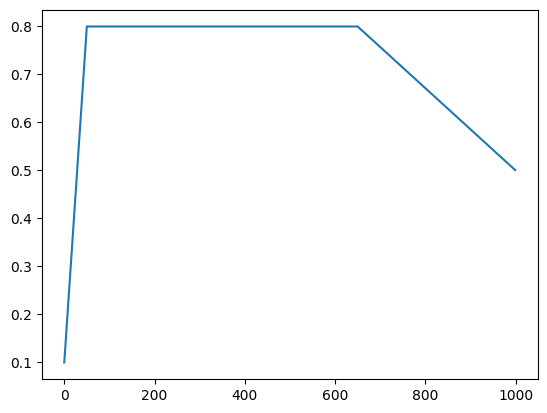

In [47]:
# @launchit.disable
steps_count = 1000
q = get_trapezoid_lr_anneal(0.1, 0.8, 0.5, steps_count)
lrs = []

for s in range(steps_count):
    lr = q(s)
    lrs.append(lr)

plt.plot(np.arange(steps_count), lrs);

### shark_fin

In [48]:
def get_shark_fin_lr_anneal(start_value, steps_count, warmup_steps_fraction=0.05):
    warmup_steps_count = int(steps_count * warmup_steps_fraction)

    def anneal_param(step):
        if step < warmup_steps_count:
            return start_value * (step / warmup_steps_count)
            
        progress = (step - warmup_steps_count) / max(1, steps_count - warmup_steps_count)
        return start_value * max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress))) # decays to 5% of max LR

    return anneal_param

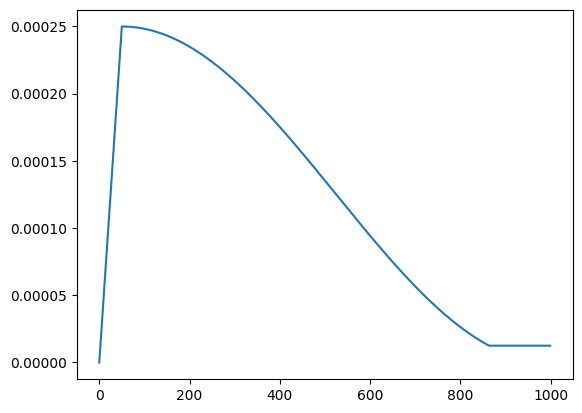

In [49]:
# @launchit.disable
steps_count = 1000
q = get_shark_fin_lr_anneal(0.00025, steps_count)
lrs = []

for s in range(steps_count):
    lr = q(s)
    lrs.append(lr)

plt.plot(np.arange(steps_count), lrs);

## Configure

In [50]:
# @launchit.disable
# @launchit.collect

# Training procedure params (PPO related) 
HP.ppo.global_steps_count = 10_000 # total number of steps 
HP.ppo.rollout_steps_count = 128 # how many steps to run in a single policy rolllout

HP.ppo.epochs_count = 2 
HP.ppo.minibatches_count = 4

HP.ppo.gamma = 0.997 # return discount factor gamma
HP.ppo.gae_lambda = 0.95 # lambda for the general advantage estimation

HP.ppo.clip_coef = 0.1 # the surrogate clipping coefficient
HP.ppo.clip_vloss = True # Toggles whether or not to use a clipped loss for the value function, as per the paper
HP.ppo.vf_coef = 0.5 # coefficient of the value function
HP.ppo.max_grad_norm = 0.5 # the maximum norm for the gradient clipping
HP.ppo.target_kl = None # e target KL divergence threshold
HP.ppo.norm_adv = True # Toggles advantages normalization
HP.ppo.prediction_coef = 0.1 # coefficient of the loss for observation emb. prediction, if set to 0.0 the prediction loss is not used
HP.ppo.optimizer = 'AdamW'
HP.ppo.is_parallel_teacher_forcing = False

# Video params
HP.video.capture_policy = 'every(1000000)' # video capture policy depending on steps

# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'env': {'ident': 'FrostbiteNoFrameskip-v4',
         'render_mode': 'rgb_array',
         'count': 32,
         'is_episodic_life': True,
         'actions_count': 6},
 'agent': {'layers_count': 3,
           'heads_count': 4,
           'd_model': 384,
           'sequence_length': 16,
           'positional_encoding': 'absolute'},
 'video': {'capture_policy': 'every(1000000)'},
 'ppo': {'global_steps_count': 10000,
         'rollout_steps_count': 128,
         'minibatches_count': 4,
         'epochs_count': 2,
         'gamma': 0.997,
         'gae_lambda': 0.95,
         'clip_coef': 0.1,
         'clip_vloss': True,
         'vf_coef': 0.5,
         'max_grad_norm': 0.5,
         'target_kl': None,
         'norm_adv': True,
         'prediction_coef': 0.1,
         

## Create

In [51]:
# @launchit.disable_2
capture_video_manager = CaptureVideoManager(HP.video.capture_policy)

ump = hp_parse_universal_module(HP.ppo.optimizer)
assert not ump.args
optimizer = getattr(torch.optim, ump.module_name)(LS.agent.parameters(), **ump.kwargs)

In [52]:
# @launchit.disable_2
game_stats_mafs = dict(
    life_stats=dict(l=RecursiveMovingAverageFilter(max_n=100), r=RecursiveMovingAverageFilter(max_n=100)),
    episode_stats=dict(l=RecursiveMovingAverageFilter(max_n=100), r=RecursiveMovingAverageFilter(max_n=100)),
)
clip_fracs_af = RecursiveAverageFilter()

dataset = Dataset(
    envs_count=HP.env.count,
    observation_space_shape=LS.agent.params.observation_space_shape, 
    rollout_steps_count=HP.ppo.rollout_steps_count, 
    sequence_length=HP.agent.sequence_length, 
    batches_count=HP.ppo.minibatches_count,
    is_shuffled=True,
    is_next_obs=HP.ppo.prediction_coef > 0,
    is_ptf=HP.ppo.is_parallel_teacher_forcing,
    is_debug=False,
)

for name, v in dataset.shared_tensors.items():
    if v is not None:
        assert v.is_shared(), f'{name} is not shared'
        LOG(f'{name:>28}: {str(v.device):>6}, {str(v.dtype):>15}, {v.shape}')

rollout_manager = RolloutManager(
    LS.agent, 
    env_inds=torch.arange(HP.env.count), 
    rollout_steps_count=HP.ppo.rollout_steps_count, 
    prologue_size=dataset.prologue_size,
    random_seed=HP.system.random_seed,
    game_modifs=LS.curriculum.get_plan_item(0).game_modifs,
)

                         obs: cuda:0,   torch.float32, torch.Size([32, 143, 1, 84, 84])
                  obs_pmasks: cuda:0,   torch.float32, torch.Size([32, 143, 16])
                     actions: cuda:0,     torch.int64, torch.Size([32, 143])
            action_log_probs: cuda:0,   torch.float32, torch.Size([32, 143])
                      values: cuda:0,   torch.float32, torch.Size([32, 143])
                    next_obs: cuda:0,   torch.float32, torch.Size([32, 143, 1, 84, 84])
                  advantages: cuda:0,   torch.float32, torch.Size([32, 143])
                     returns: cuda:0,   torch.float32, torch.Size([32, 143])
Envs created, env_inds=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]
Envs reset


In [53]:
def tablify_game_modifs_probs(game_modifs_probs):
    columns = []
    
    for i in range(len(game_modifs_probs)):
        columns.append(f'L{i:02}')

    markdown = ''
    markdown += '|' + '|'.join(columns) + '|\n'
    markdown += '|' + '|'.join(map(lambda c: '-', columns)) + '|\n'

    columns.clear()
    
    for p in game_modifs_probs:
        columns.append(f'{p * 100:.0f}%')

    markdown += '|' + '|'.join(columns) + '|\n'
    return markdown

## Train

In [54]:
# @launchit.disable_2
pbar = tqdm(total=HP.ppo.global_steps_count)
global_step = 0
global_step_inc = HP.env.count * HP.ppo.rollout_steps_count

while global_step < HP.ppo.global_steps_count:
    start_time = time.time()
    
    # ADVANCE THROUGH CURRICULUM
    curriculum_plan_item = LS.curriculum.get_plan_item(global_step / HP.ppo.global_steps_count)
    for param_group in optimizer.param_groups: param_group["lr"] = curriculum_plan_item.learn_rate
    ent_coef = curriculum_plan_item.ent_coef

    # ROLLOUT
    rr = rollout_manager.rollout(dataset.shared_tensors, game_modifs=curriculum_plan_item.game_modifs)

    for k in game_stats_mafs:
        for stats_item in rr[k]:
            game_stats_mafs[k]['l'](stats_item['l'])
            game_stats_mafs[k]['r'](stats_item['r'])

    # TRAINING
    for epoch in range(HP.ppo.epochs_count):
        for batch in dataset:
            agent_output = LS.agent.replay_experience(
                X=batch.obs, 
                padding_masks=batch.obs_pmasks,
                actions=batch.actions, 
                predict_next_obs_emb=HP.ppo.prediction_coef > 0.0,
            )

            if HP.ppo.is_parallel_teacher_forcing:
                valid_inds = ~(batch.obs_pmasks.bool()).flatten()
                new_action_log_probs = agent_output.action_log_probs.flatten()[valid_inds]
                new_prob_entropies = agent_output.prob_entropies.flatten()[valid_inds]
                new_values = agent_output.values.flatten()[valid_inds]
                b_advantages = batch.advantages.flatten()[valid_inds]
                b_action_log_probs = batch.action_log_probs.flatten()[valid_inds]
                b_returns = batch.returns.flatten()[valid_inds]
                b_values = batch.values.flatten()[valid_inds]
            else:
                assert torch.all(batch.obs_pmasks[:,-1] == 0)
                new_action_log_probs = agent_output.action_log_probs
                new_prob_entropies = agent_output.prob_entropies
                new_values = agent_output.values
                b_advantages = batch.advantages
                b_action_log_probs = batch.action_log_probs
                b_returns = batch.returns
                b_values = batch.values

            # Policy loss
            if HP.ppo.norm_adv:
                b_advantages = (b_advantages - b_advantages.mean()) / (b_advantages.std() + 1e-8)

            logratio = new_action_log_probs - b_action_log_probs
            ratio = torch.exp(logratio)
            pgloss1 = -b_advantages * ratio
            pgloss2 = -b_advantages * torch.clamp(ratio, 1.0 - HP.ppo.clip_coef, 1.0 + HP.ppo.clip_coef)
            pg_loss = torch.max(pgloss1, pgloss2).mean()

            # Value loss
            v_loss_unclipped = (new_values - b_returns) ** 2 
            
            if HP.ppo.clip_vloss:
                v_loss_clipped = b_values + (new_values - b_values).clamp(min=-HP.ppo.clip_coef, max=HP.ppo.clip_coef)
                v_loss = torch.max(v_loss_unclipped, (v_loss_clipped - b_returns) ** 2).mean()
            else:
                v_loss = v_loss_unclipped.mean()

            # Entropy loss
            entropy_loss = new_prob_entropies.mean()

            # Combined losses
            loss = pg_loss - ent_coef * entropy_loss + HP.ppo.vf_coef * v_loss
            
            if HP.ppo.prediction_coef > 0.0:
                next_obs_emb = LS.agent.get_obs_emb(batch.next_obs.unsqueeze(1)).detach().squeeze(1)
                prediction_loss = F.mse_loss(agent_output.next_obs_emb, next_obs_emb)
                loss += HP.ppo.prediction_coef * prediction_loss

            optimizer.zero_grad()
            loss.backward()
            grad_norm_groups = get_grad_norm_groups(LS.agent, ['cnn', 'transformer', 'actor', 'critic', 'predictor'])
            grad_norm = torch.nn.utils.clip_grad_norm_(LS.agent.parameters(), max_norm=HP.ppo.max_grad_norm)
            optimizer.step()

            with torch.no_grad():
                # calculate approx_kl http://joschu.net/blog/kl-approx.html
                approx_kl = ((ratio - 1) - logratio).mean()
                clip_fracs_af(((ratio - 1.0).abs() > HP.ppo.clip_coef).float().mean().item())

        if HP.ppo.target_kl is not None and approx_kl > HP.ppo.target_kl:
            break

    var_y = torch.var(dataset.returns)
    explained_var = lu.when(var_y == 0, np.nan, 1 - torch.var(dataset.returns - dataset.values) / var_y)

    # REPORT
    summary_writer.add_scalar('charts/sps', global_step_inc / (time.time() - start_time), global_step)
    
    summary_writer.add_scalar('curriculum/learning_rate', curriculum_plan_item.learn_rate, global_step)
    summary_writer.add_scalar('curriculum/entropy_coefficient', ent_coef, global_step)
    summary_writer.add_text('curriculum/game_modifs_probs', tablify_game_modifs_probs(curriculum_plan_item.game_modifs_probs), global_step)
    
    summary_writer.add_scalar('grad/grad_norm', grad_norm, global_step)

    for grad_norm_group_name, grad_norm_group_value in grad_norm_groups.items():
        summary_writer.add_scalar(f'grad/grad_norm_{grad_norm_group_name}', grad_norm_group_value, global_step)
    
    summary_writer.add_scalar('losses/loss', loss, global_step)
    summary_writer.add_scalar('losses/policy_loss', pg_loss, global_step)
    summary_writer.add_scalar('losses/value_loss', v_loss, global_step)
    summary_writer.add_scalar('losses/entropy_loss', entropy_loss, global_step)
    summary_writer.add_scalar('losses/prediction_loss', lu.when(HP.ppo.prediction_coef > 0, lambda: prediction_loss, 0), global_step)
    summary_writer.add_scalar('losses/approx_kl', approx_kl, global_step)
    summary_writer.add_scalar('losses/clipfrac', clip_fracs_af.reset(), global_step)
    summary_writer.add_scalar('losses/explained_variance', explained_var, global_step)

    summary_writer.add_scalar('game_stats/episode_l', game_stats_mafs['episode_stats']['l'].v, global_step)
    summary_writer.add_scalar('game_stats/episode_r', game_stats_mafs['episode_stats']['r'].v, global_step)
    summary_writer.add_scalar('game_stats/life_l', game_stats_mafs['life_stats']['l'].v, global_step)
    summary_writer.add_scalar('game_stats/life_r', game_stats_mafs['life_stats']['r'].v, global_step)
    
    summary_writer.add_scalar('rollout/value_mean', dataset.values.mean(), global_step)
    summary_writer.add_scalar('rollout/advantage_mean', dataset.advantages.mean(), global_step)

    # VIDEO
    if capture_video_manager.should_capture_video(global_step) or (global_step + global_step_inc >= HP.ppo.global_steps_count):
        if capture_video_manager.is_busy():
            capture_video_manager.upload_captured_video(is_drain=True)

        game_modifs_list = [[]]
        game_modifs_list.extend(LS.curriculum.get_game_modifs_list())
        capture_video_manager.schedule_capture_video(global_step, game_modifs_list=game_modifs_list)

    capture_video_manager.upload_captured_video()
    summary_writer.flush()

    # min is used to not overflow progress bar at the end (global_step could get > HP.ppo.global_step_size)
    pbar.update(min(global_step_inc, HP.ppo.global_steps_count - global_step)) 
    global_step += global_step_inc

capture_video_manager.upload_captured_video(is_drain=True)
summary_writer.flush()
pbar.close()

  0%|          | 0/10000 [00:00<?, ?it/s]

## Save

In [55]:
# @launchit.disable_2
artifact_registry = LS.new_artifact_registry()
lc = HP.launch_component()

with io.BytesIO() as b:
    torch.save(LS.agent.state_dict(), b)
    artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='pt', asset_classifier='agent', replace=True)

with io.StringIO() as b:
    json.dump(dataclasses.asdict(LS.agent.params), b)
    artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='agent_params', replace=True)

# LaunchIt!

## TRAIN

In [10]:
# @launchit.disable
launchit_t0 = time.time()

In [11]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    lc = HP.launch_component()
    component_version = int(Autoincrement.get(lc.uri))
    assert component_version > 0, component_version
    artifact_registry = LS.new_artifact_registry(is_real=True)
    artifact_registry.register_component(lc.name, component_version)
    LOG(f'Model instance registered, version={component_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        PROJECT_ROOT_PATH2=CONFIG.project_root_path,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=component_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN.value,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=component_version, expandvars=expandvars, collect_inds=[1], disable_inds=[1])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=12
Creating /home/misha/dev/mine/neurolab/17_rl/17e_ppo_tr_atari_mp_09-launch12.ipynb
Created launch notebook "/home/misha/dev/mine/neurolab/17_rl/17e_ppo_tr_atari_mp_09-launch12.ipynb"


I've played around with the states idea and refined it. I think I don't actually need states. What I need is that agent must think in sequences of actions, e.g. 10 actions at once. Sequences generated on adjacent states must overlap: i.e. one must continue other. Of course there are situations when sequence must change (e.g. new sudden threat is detected), but in most cases there must a continuity. Due to continuity I don't even need to bother with controlling entropy of sequence - continuity will naturally ban erratic and random actions. This way agent will naturally develop some library of stereotypic trajectories. And this library will be dynamic. 
Next. By making agent to think in action sequences I can even speed up rollout speed by times - that's because I don't even need to call agent on every observation. This resembles human ability to learn: we start acquiring new skill slowly but then most actions are made automatically. The only point is how to break from current action sequence on sudden new information. But that's can be posponed for now.
So I need to make agent to think in action sequences. Let's elaborate how I must change my agents code.

## Docker launch

In [58]:
# @launchit.disable
launchit_t0 = time.time()

In [59]:
# @launchit.collect_2
# @launchit.disable
if not os.path.exists(os.path.join(project_root_path, '.docker_launch')) and '${LAUNCHIT_FNAME}' != '$' + '{LAUNCHIT_FNAME}':
    # second condition (with LAUNCHIT_FNAME) is required to prevent execution in MASTER_NOTEBOOK mode during "Run all cells"
    
    import subprocess
    import tempfile
    
    notebook_fname = '${LAUNCHIT_FNAME}'
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    subproject_name = os.path.basename(os.path.dirname(notebook_fname))
    dockerfile_content = f'''
FROM neurolab_source:latest
WORKDIR /neurolab
RUN git pull --rebase
WORKDIR /neurolab/{subproject_name}
COPY {os.path.basename(notebook_fname)} .
RUN touch /neurolab/.docker_launch
CMD ["papermill", "{os.path.basename(notebook_fname)}", "{os.path.basename(notebook_fname)}", "--stdout-file=/dev/stdout"]
    '''

    with tempfile.NamedTemporaryFile(mode='w+t', suffix='.Dockerfile') as dockerfile:
        with open(dockerfile.name, 'w') as f:
            f.write(dockerfile_content)

        image_tag = 'cr.selcloud.ru/docker/${MODEL_NAME}' + ':' + '${MODEL_VERSION}'
        subprocess.run(
            ['docker', 'buildx', 'build', '-f', dockerfile.name, '-t', image_tag, '.', '--load'],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )
        subprocess.run(
            ['docker', 'push', image_tag],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )

In [60]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    lc = HP.launch_component()
    component_version = int(Autoincrement.get(lc.uri))
    assert component_version > 0, component_version
    artifact_registry = LS.new_artifact_registry(is_real=True)
    artifact_registry.register_component(lc.name, component_version)
    LOG(f'Model instance registered, version={component_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH='/neurolab',
        PROJECT_ROOT_PATH2=CONFIG.project_root_path,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=component_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN.value,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=component_version, expandvars=expandvars, collect_inds=[1,2], disable_inds=[1])
    LOG(f'Created docker launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Skip launchit due to mass "Run Cells"


## Optuna (model selection)

### Templates

In [61]:
# @launchit.disable
# @launchit.collect_3
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    
    match study_serial:
        case 1:
            HP = Hyperparameters()
            HP.random_seed = 42
            assert False
        case _:
            assert False, f'Unsupported {study_serial=}'            

### Unleash

In [62]:
# @launchit.disable
def get_optimize_directions(lg):
    match lg:
        case LaunchGoal.TRAIN_MODEL:
            return ['minimize']
        case _:
            assert False, f'Unsupported {lg=}'

lg = LaunchGoal.TRAIN_MODEL
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=lg.value,
)
study_serial = 1
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_{study_serial}'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[],
    run_path=CONFIG.run_path,
    study_serial=study_serial,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(lg),
)
rop_tasks = [rop_task] * 1
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

AttributeError: type object 'LaunchGoal' has no attribute 'TRAIN_MODEL'

In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")